In [1]:
import os
import json
from report_fct import run_all
from natsort import natsorted
import pandas as pd
summary_path = "summary_enriched.json"

def load_summary_intervals(summary_file="summary.json"):
    with open(summary_file, "r") as f:
        return {r["run"]: r["intervals"] for r in json.load(f)}
    
df_all = pd.read_csv("all_data.csv", low_memory=False)
summary = load_summary_intervals("summary.json")

smooth_frac={
        "VMG": 0.2,
        "Heel_Lwd": 0.35,
        "Trim": 0.35,
        "central": 0.35,
        "feet_load": 0.35,
    }

# Only Upwind

## Only Gian Upwind:

,rank,Run,rider_name,role,pol_ratio,TWS,avg_vmg,avg_sog,avg_cog,cog_std,avg_rot,heel,trim,central,lateral,foil_brand,gain_per_min_vmg,gain_per_min_forward,gain_per_min_lateral
0,1,26_11_2025_Run10 (interval 1),Gian Stragiotti,master,105.487892,12.111860,20.346209,23.507712,302.048571,6.044901,0.251905,52.444248,9.783439,116.645980,1.937016,Chub,51.123770,46.220428,22.118038
1,2,26_11_2025_Run12 (interval 1),Gian Stragiotti,master,104.381635,12.549298,20.026746,23.398627,306.891959,3.310176,0.107374,49.765892,7.672756,118.757544,1.758388,Levi,66.781520,65.662650,20.251155
2,3,27_11_2025_Run9 (interval 1),Gian Stragiotti,slave,104.241561,13.276638,20.265846,23.299585,302.547681,3.549728,0.045726,53.804569,9.787643,118.903382,1.570504,Chub,59.489391,72.982957,-8.334901
3,4,26_11_2025_Run8 (interval 1),Gian Stragiotti,master,103.257655,14.927933,20.624788,23.416934,306.945826,4.206015,-0.170987,52.665255,9.760876,115.480921,1.812876,Chub,36.092176,46.192634,-10.023352
4,5,27_11_2025_Run3 (interval 1),Gian Stragiotti,slave,102.961306,12.596998,17.908790,23.603438,317.534413,4.003460,-0.151909,52.019941,10.270039,114.536284,1.738847,Chub,46.945400,58.138954,4.111073
5,6,26_11_2025_Run7 (interval 1),Gian Stragiotti,slave,102.313890,17.260709,21.184952,23.323676,312.126514,3.146936,-0.025477,51.479421,9.913087,115.603016,1.642113,Chub,60.377649,56.847390,20.831557
6,7,26_11_2025_Run14 (interval 1),Gian Stragiotti,master,102.203383,15.580441,20.180361,23.279617,308.606087,4.437895,0.048445,49.303734,7.724723,114.876961,1.865781,Levi,63.417335,64.262102,15.303447
7,8,27_11_2025_Run2 (interval 1),Gian Stragiotti,master,101.359828,12.633968,12.308071,24.515914,319.562755,5.511644,-0.108760,51.975873,10.181314,114.146316,1.621839,Chub,-7.530337,95.553618,-64.479520
8,9,26_11_2025_Run2 (interval 1),Gian Stragiotti,master,100.970632,16.140280,19.524067,23.064331,303.250254,4.545276,0.055718,52.842675,9.843312,117.336634,1.997015,Chub,37.355262,55.885322,-19.098407
9,10,26_11_2025_Run9 (interval 1),Gian Stragiotti,slave,100.769897,15.236875,19.525109,22.968983,307.737820,5.202736,-0.182362,52.980262,9.779960,117.290489,2.245319,Chub,61.416053,60.026980,19.434583


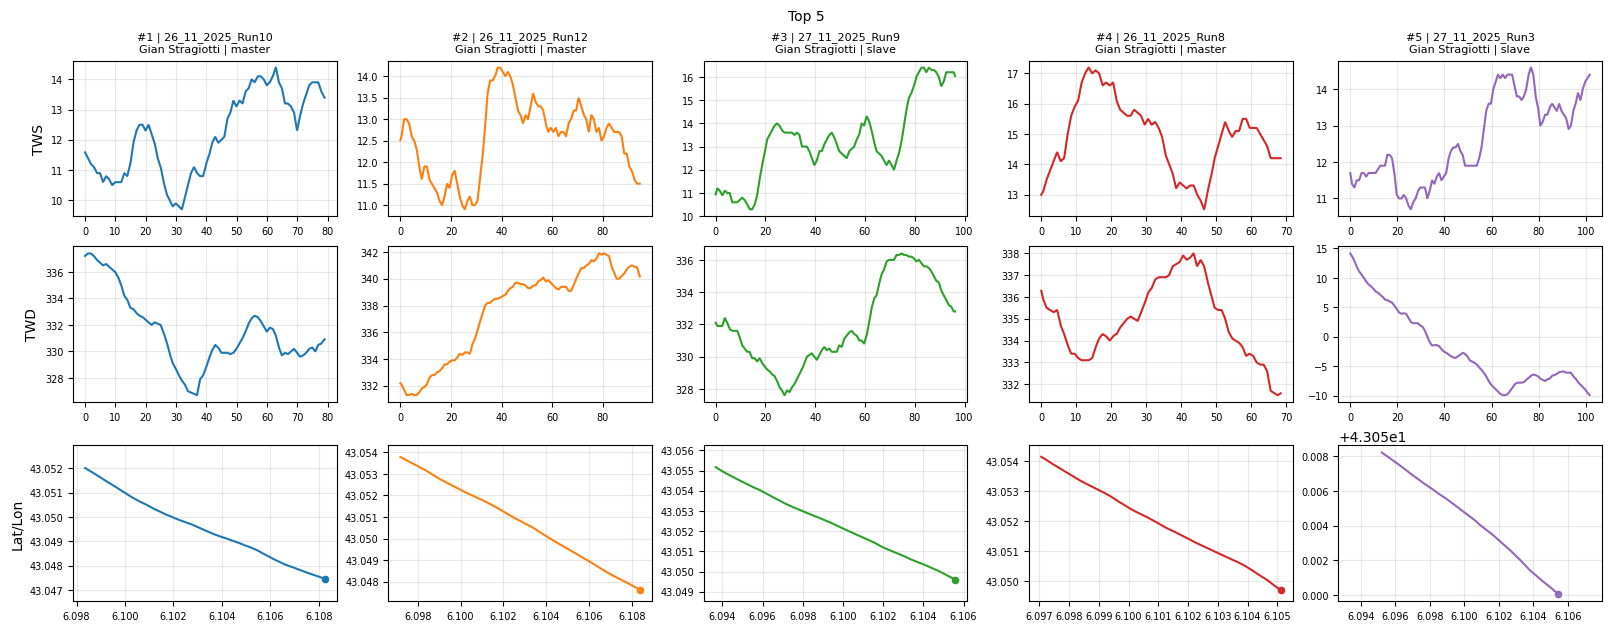

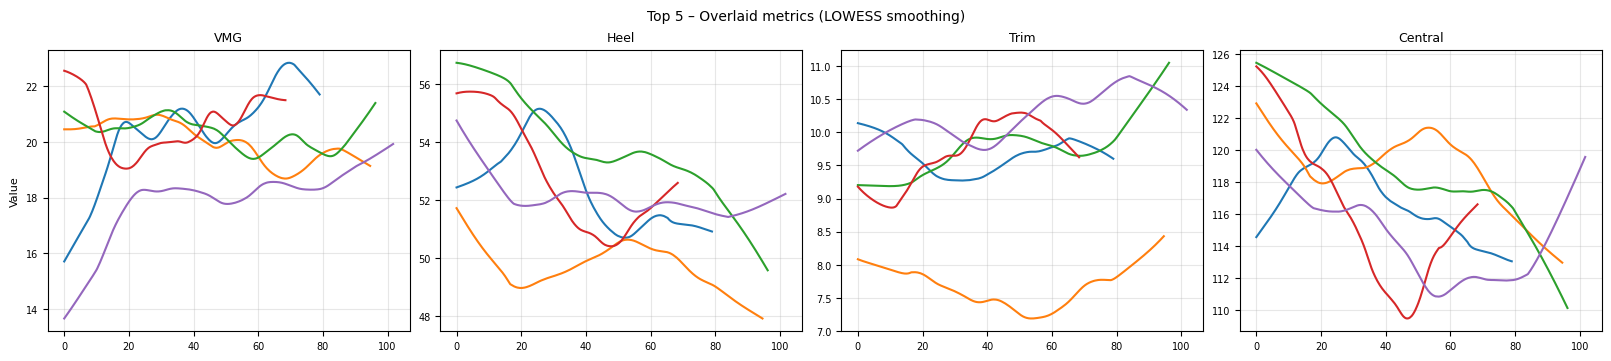

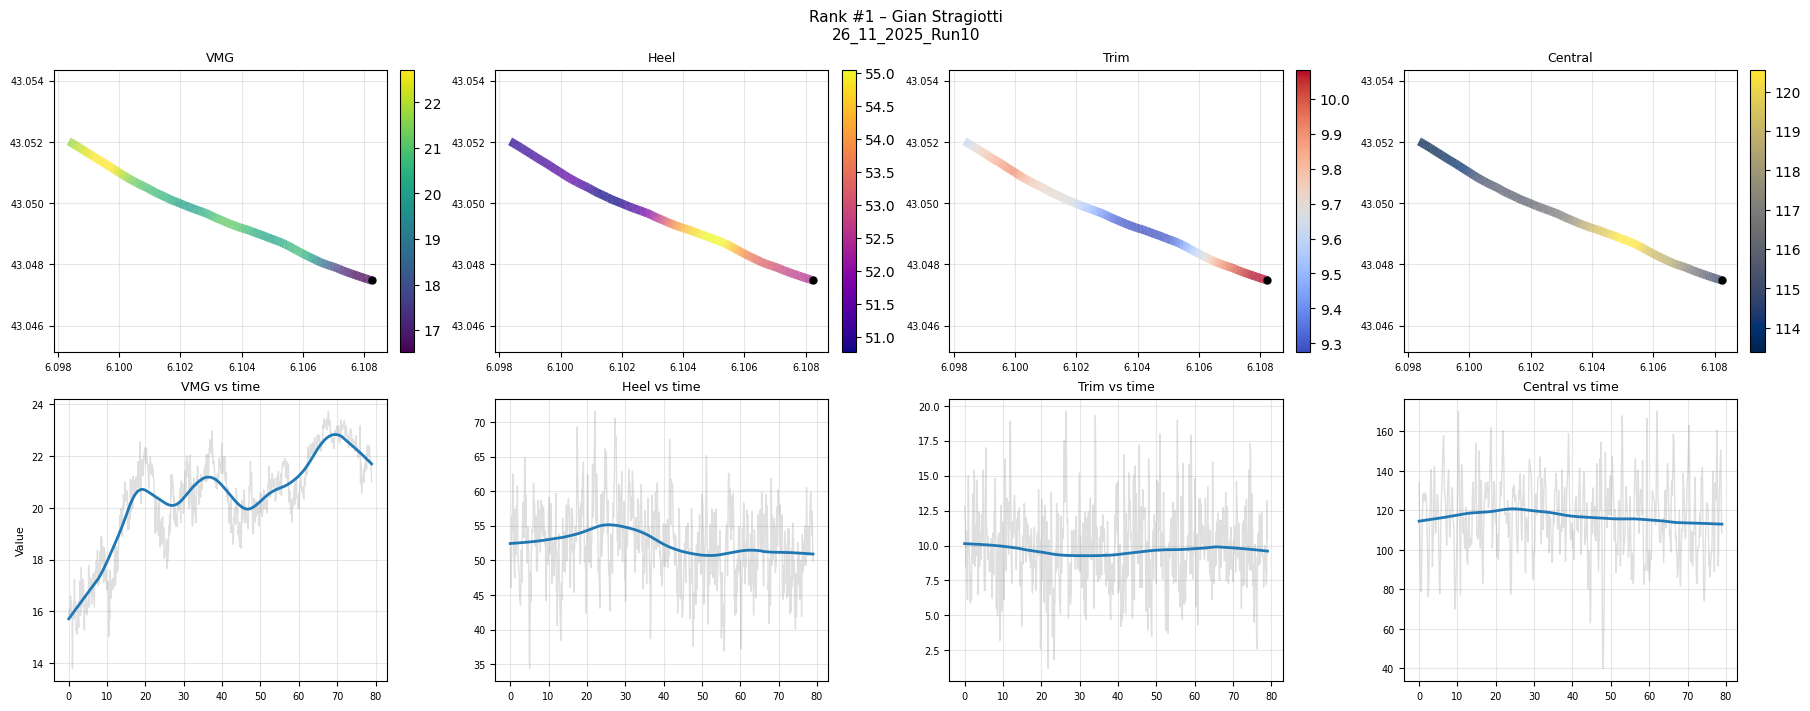

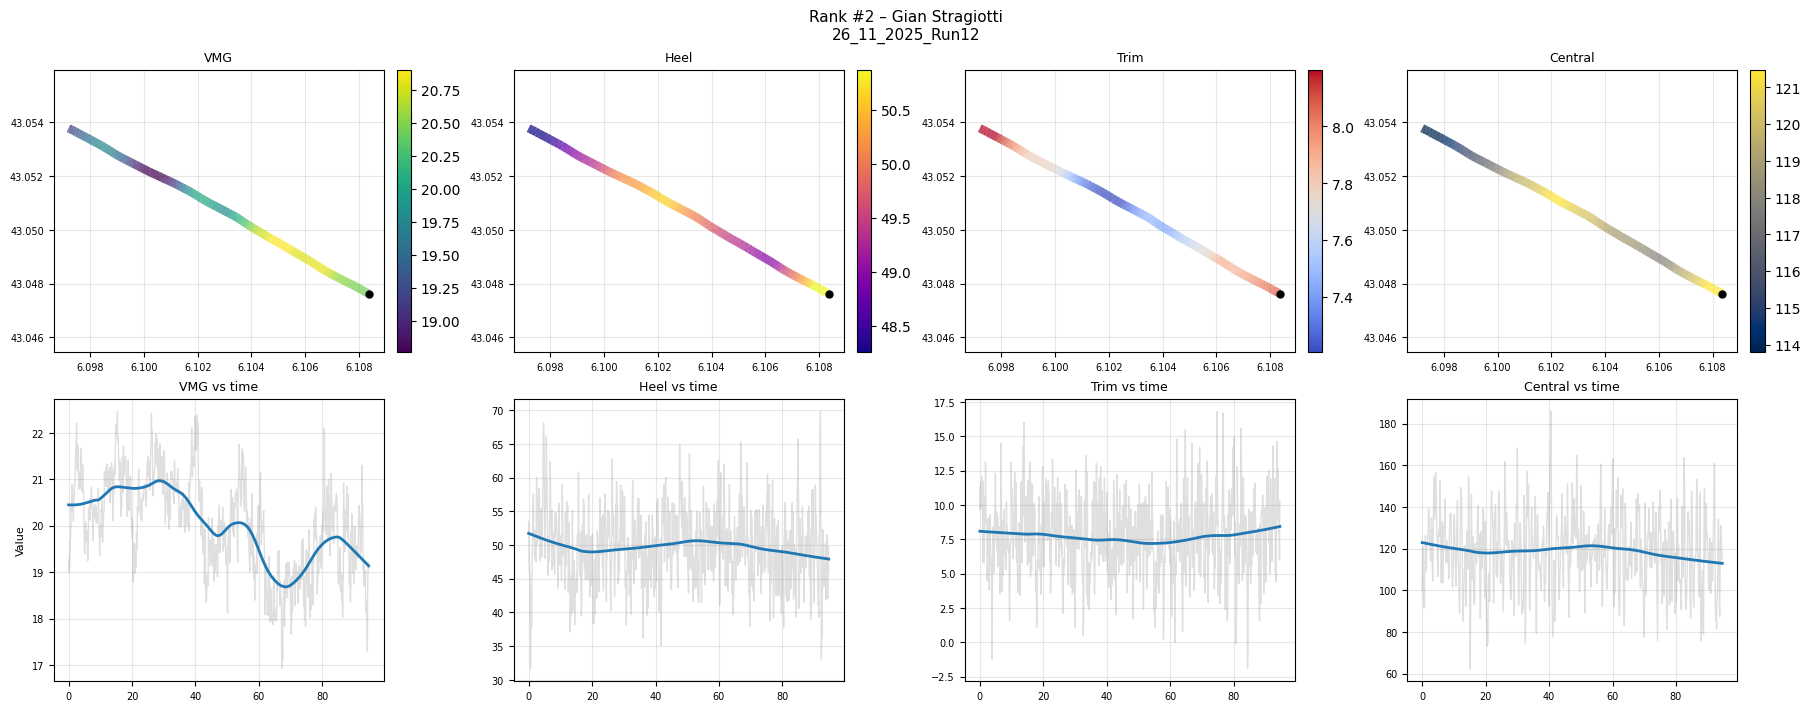

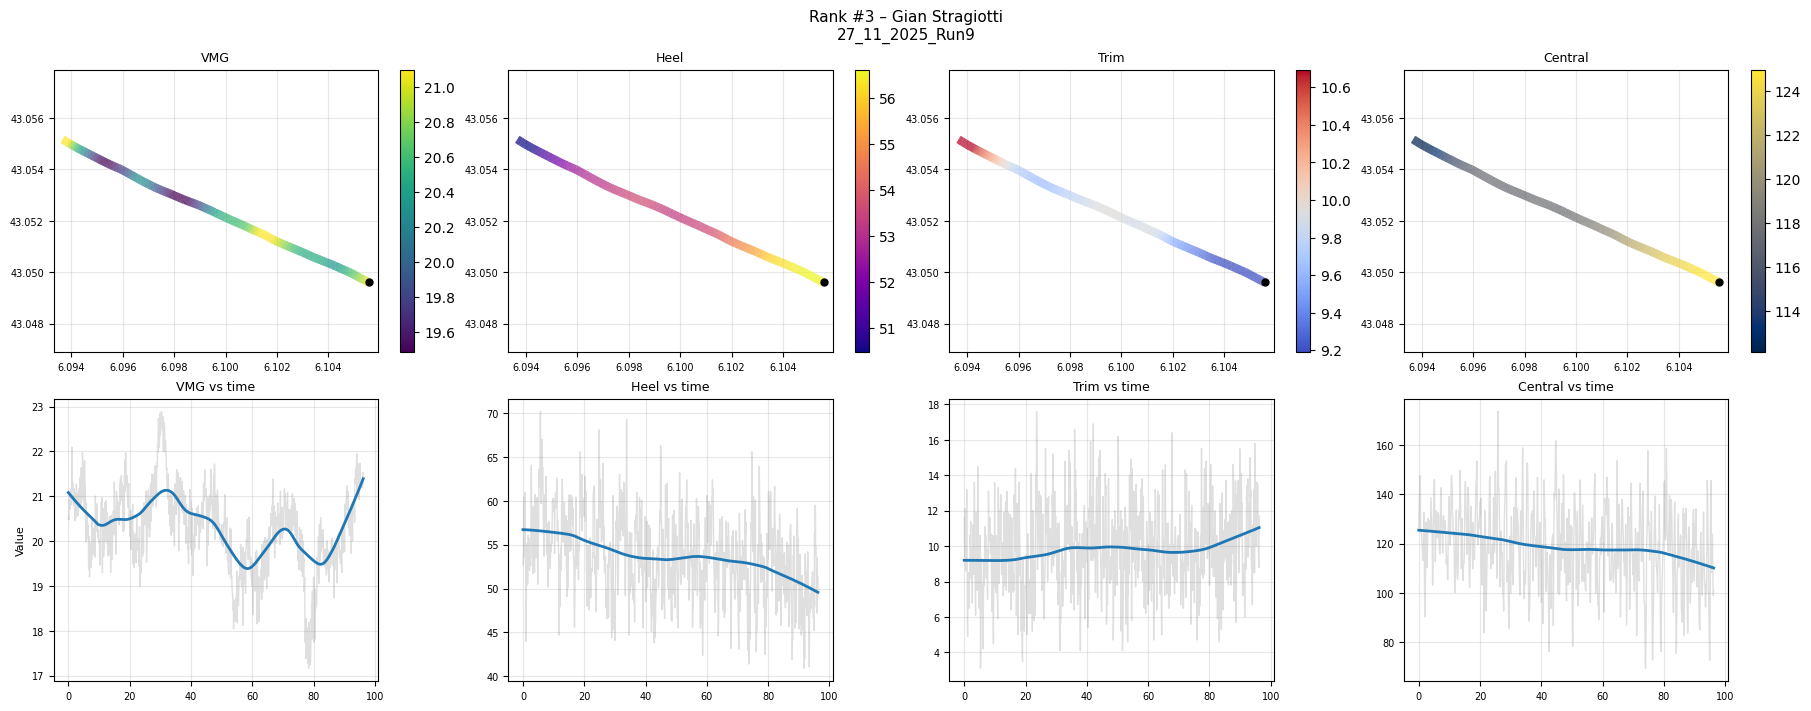

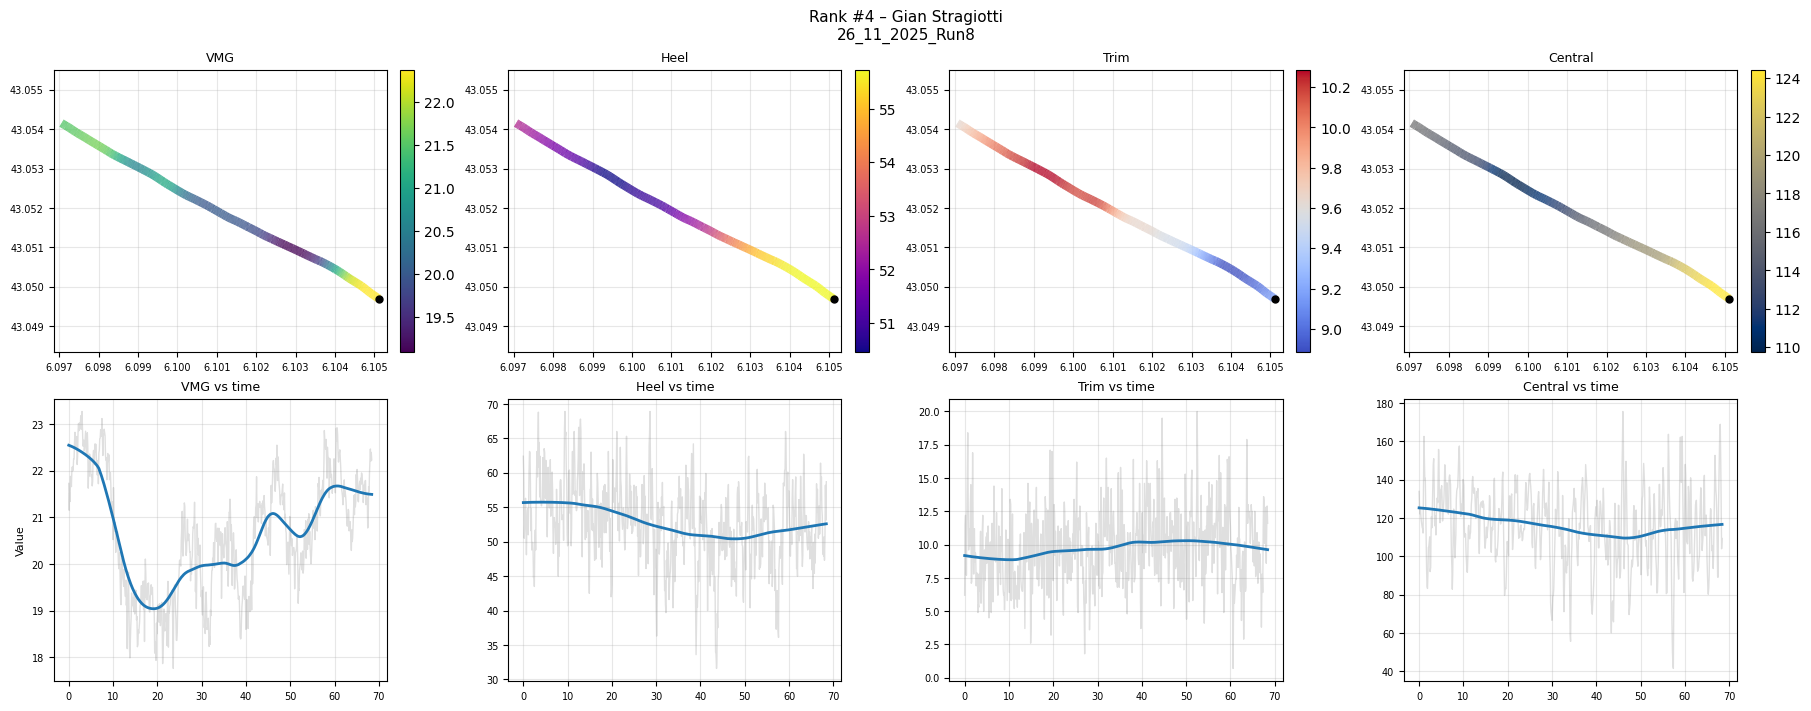

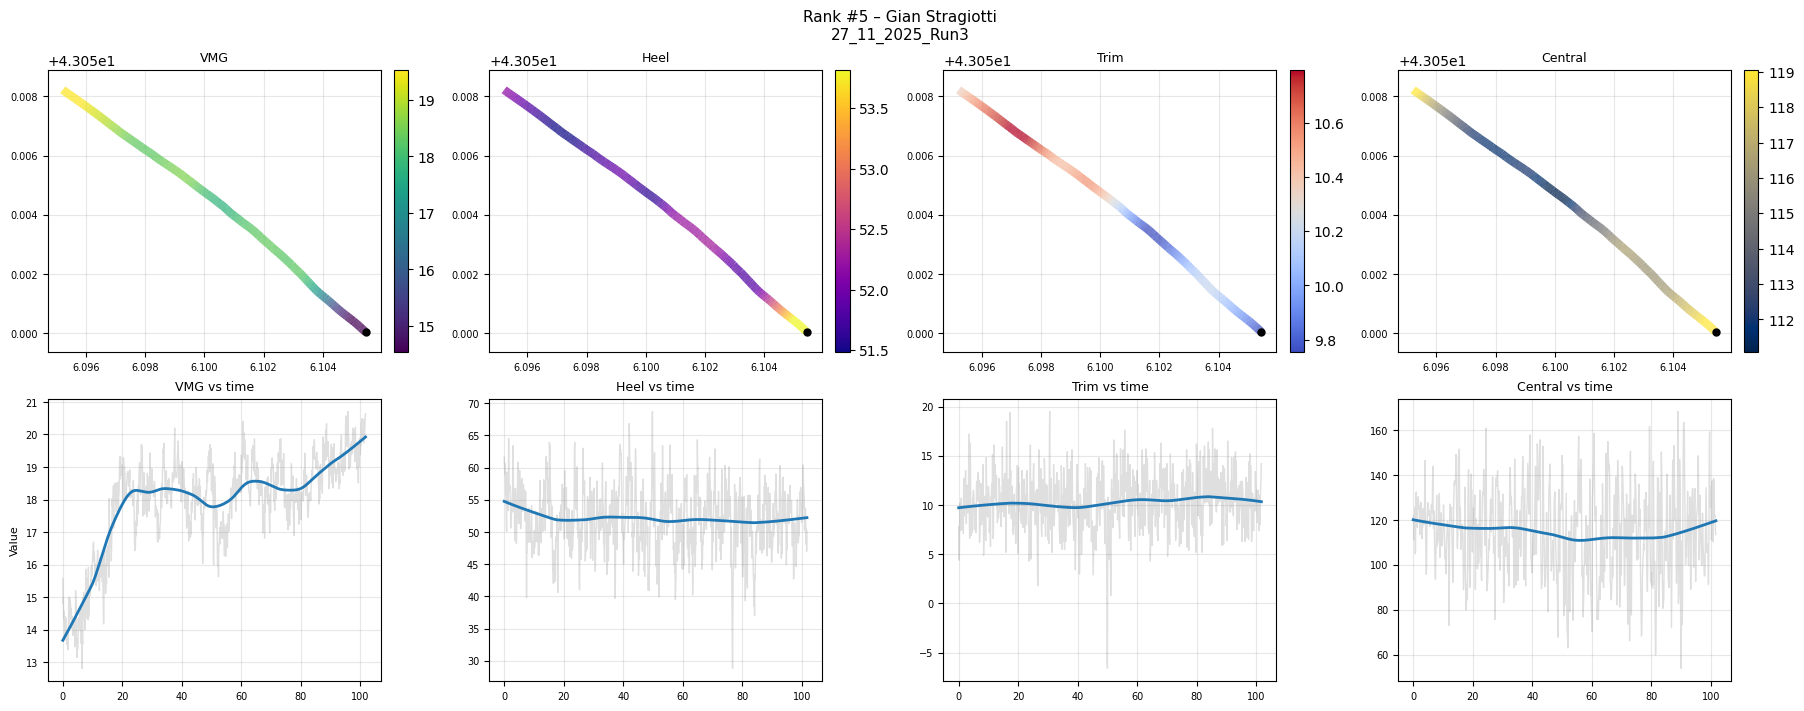

In [2]:
top_upwind_gian = run_all(df_all, summary, TOP_N=10, onlyUpwind=True, rider_name="Gian Stragiotti", smooth_frac=smooth_frac)

## Only Max Upwind:

,rank,Run,rider_name,role,pol_ratio,TWS,avg_vmg,avg_sog,avg_cog,cog_std,avg_rot,heel,trim,central,lateral,foil_brand,gain_per_min_vmg,gain_per_min_forward,gain_per_min_lateral
0,1,26_11_2025_Run10 (interval 1),Max Maeder,slave,104.633717,12.111137,18.697749,22.067554,300.178505,6.307845,0.295139,48.327954,8.361343,101.419654,6.786843,Levi,-51.123770,-46.220428,-22.118038
1,2,26_11_2025_Run12 (interval 1),Max Maeder,slave,103.422583,12.550407,17.883799,21.326216,305.109340,4.406586,0.004395,48.773573,8.279387,108.168387,7.508571,Chub,-66.781520,-65.662650,-20.251155
2,3,27_11_2025_Run9 (interval 1),Max Maeder,master,102.932679,13.276688,18.289738,20.964798,303.277190,5.129577,0.054235,50.924195,8.171340,105.087197,8.087528,Levi,-59.489391,-72.982957,8.334901
3,4,26_11_2025_Run14 (interval 1),Max Maeder,slave,102.747968,15.581281,18.177826,21.344444,306.678836,10.366879,-0.923529,50.036061,8.262525,102.874632,5.622328,Chub,-63.417335,-64.262102,-15.303447
4,5,26_11_2025_Run8 (interval 1),Max Maeder,slave,102.058376,14.927874,19.398873,21.917810,307.696117,4.895861,0.218813,46.412263,8.454891,103.018971,6.532335,Levi,-36.092176,-46.192634,10.023352
5,6,27_11_2025_Run3 (interval 1),Max Maeder,master,101.798771,12.596980,16.295741,21.714931,317.033167,4.888807,-0.006084,48.261002,8.241454,106.172970,8.293933,Levi,-46.945400,-58.138954,-4.111073
6,7,26_11_2025_Run4 (interval 1),Max Maeder,slave,100.776616,17.340805,15.966245,19.358273,300.117500,23.048158,0.258563,46.468652,9.455047,96.337516,6.678610,Chub,-123.669524,-117.627826,-43.422475
7,8,26_11_2025_Run7 (interval 1),Max Maeder,master,100.665445,17.260393,19.329406,21.613113,310.231051,3.646857,-0.029007,46.872172,8.569069,103.893764,6.378771,Levi,-60.377649,-56.847390,-20.831557
8,9,27_11_2025_Run2 (interval 1),Max Maeder,slave,100.399434,12.633386,12.595792,21.578109,325.215775,6.582990,-0.323629,48.015519,8.379239,104.441706,8.737676,Levi,7.530337,-95.553618,64.479520
9,10,26_11_2025_Run2 (interval 1),Max Maeder,slave,99.910353,16.140334,18.323242,21.278822,304.884710,4.168619,0.004459,48.406369,8.083917,109.259626,7.033532,Levi,-37.355262,-55.885322,19.098407


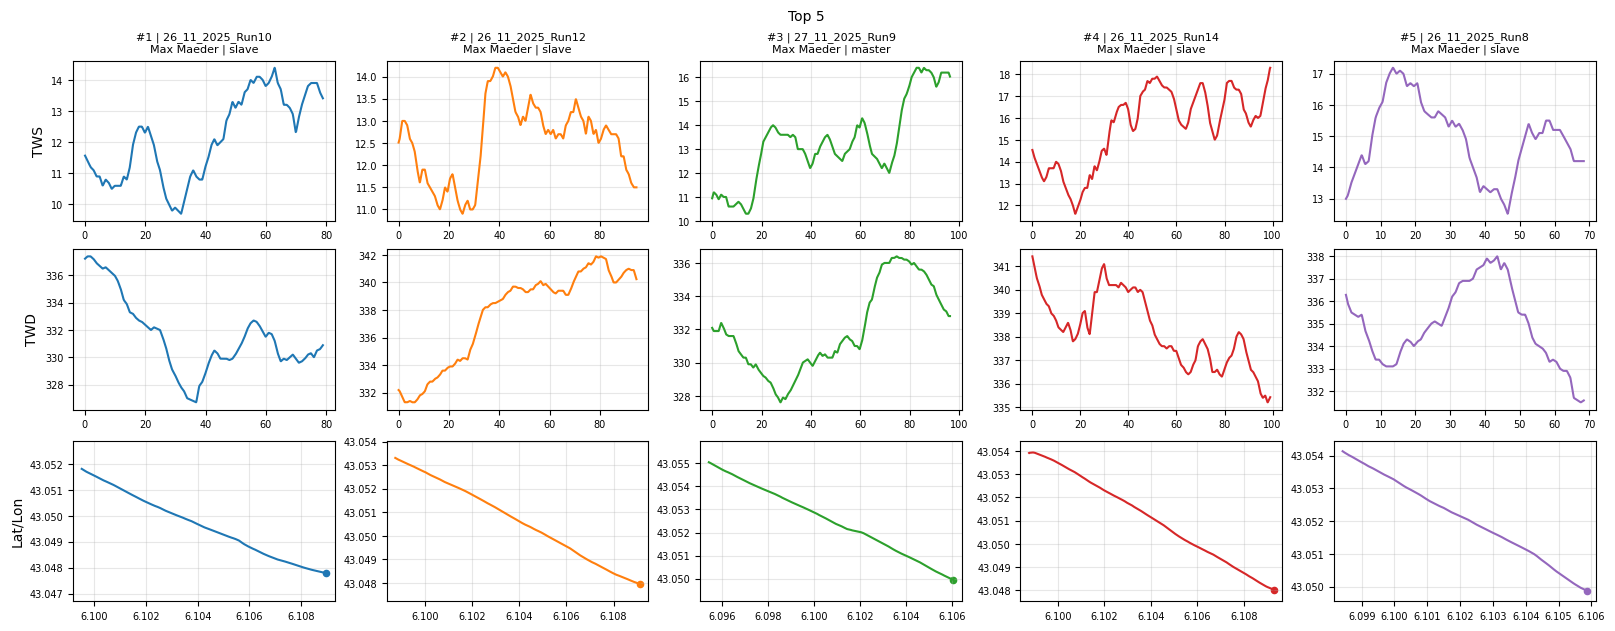

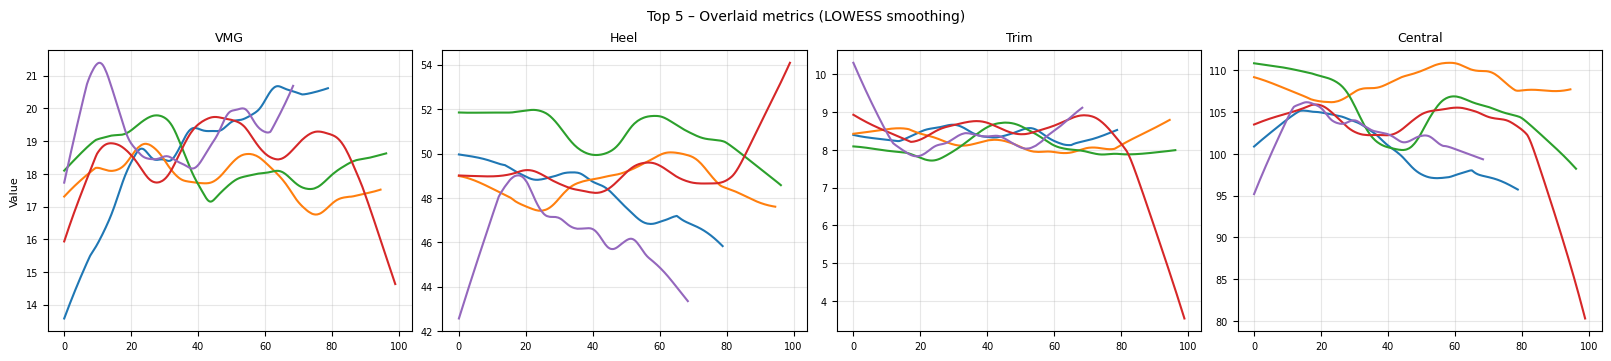

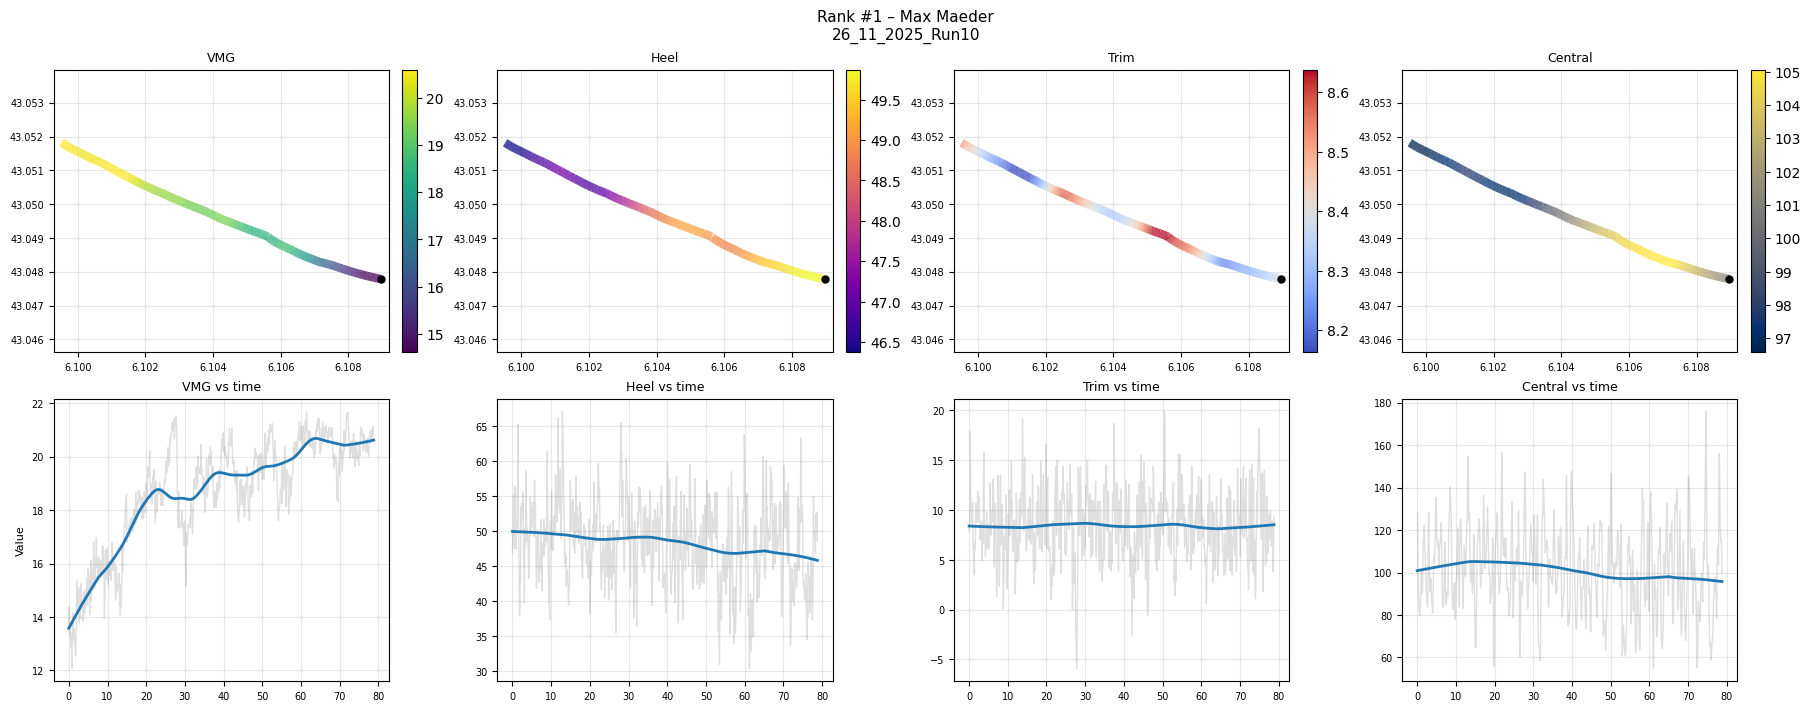

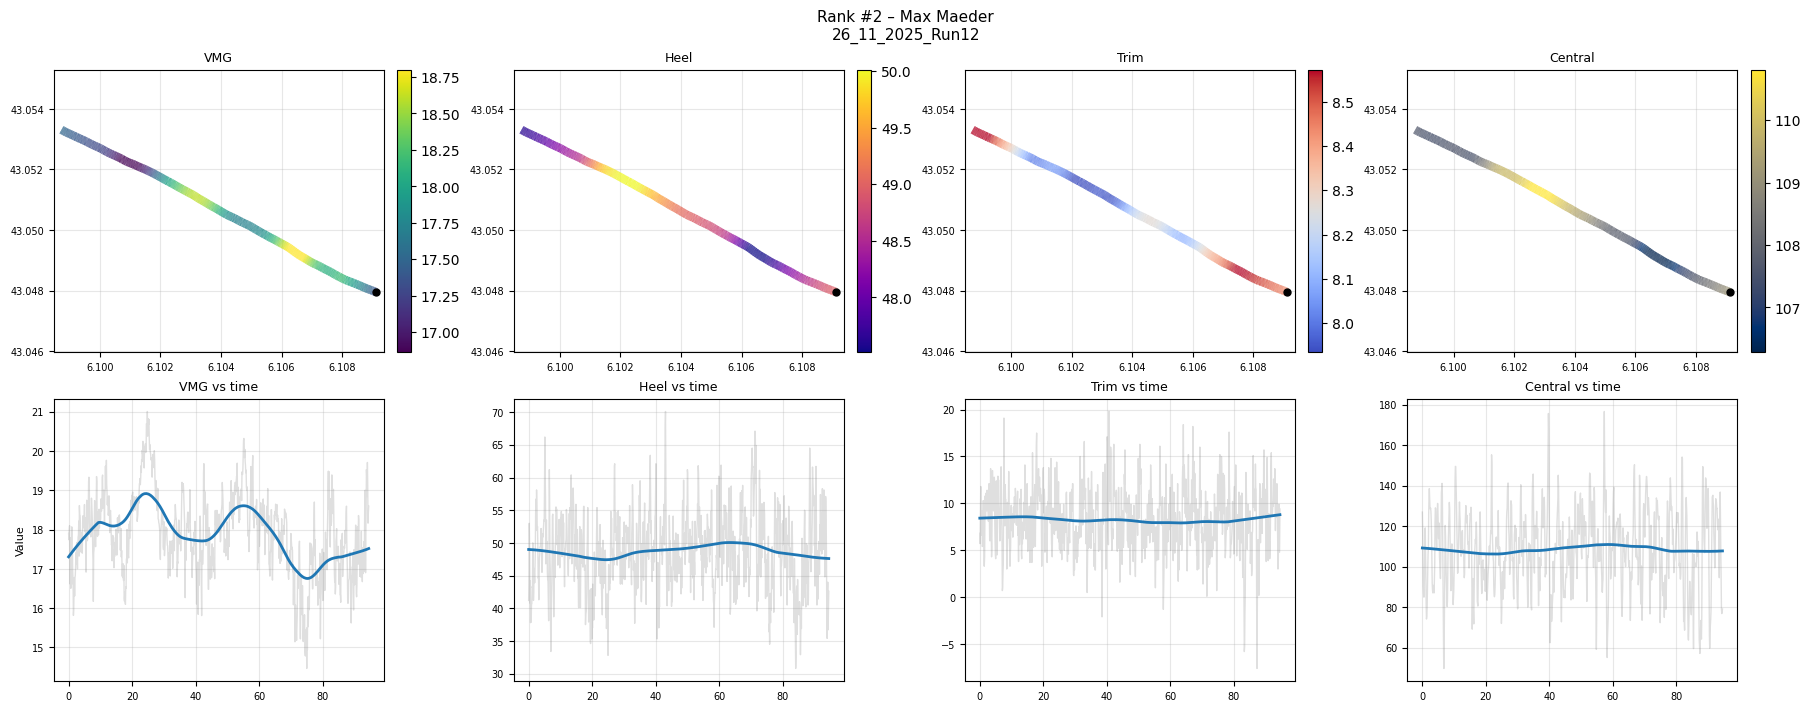

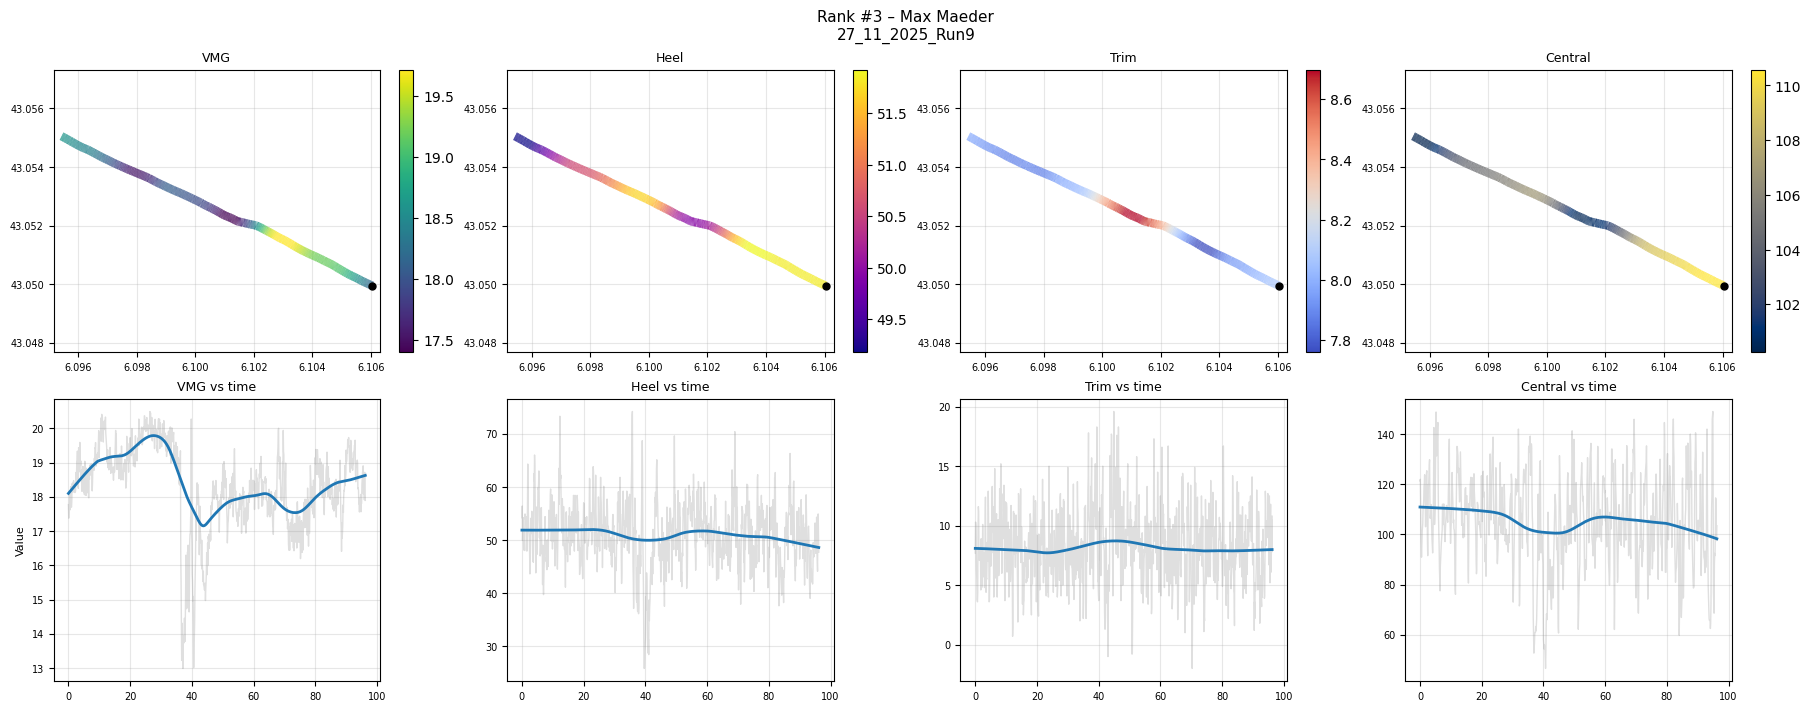

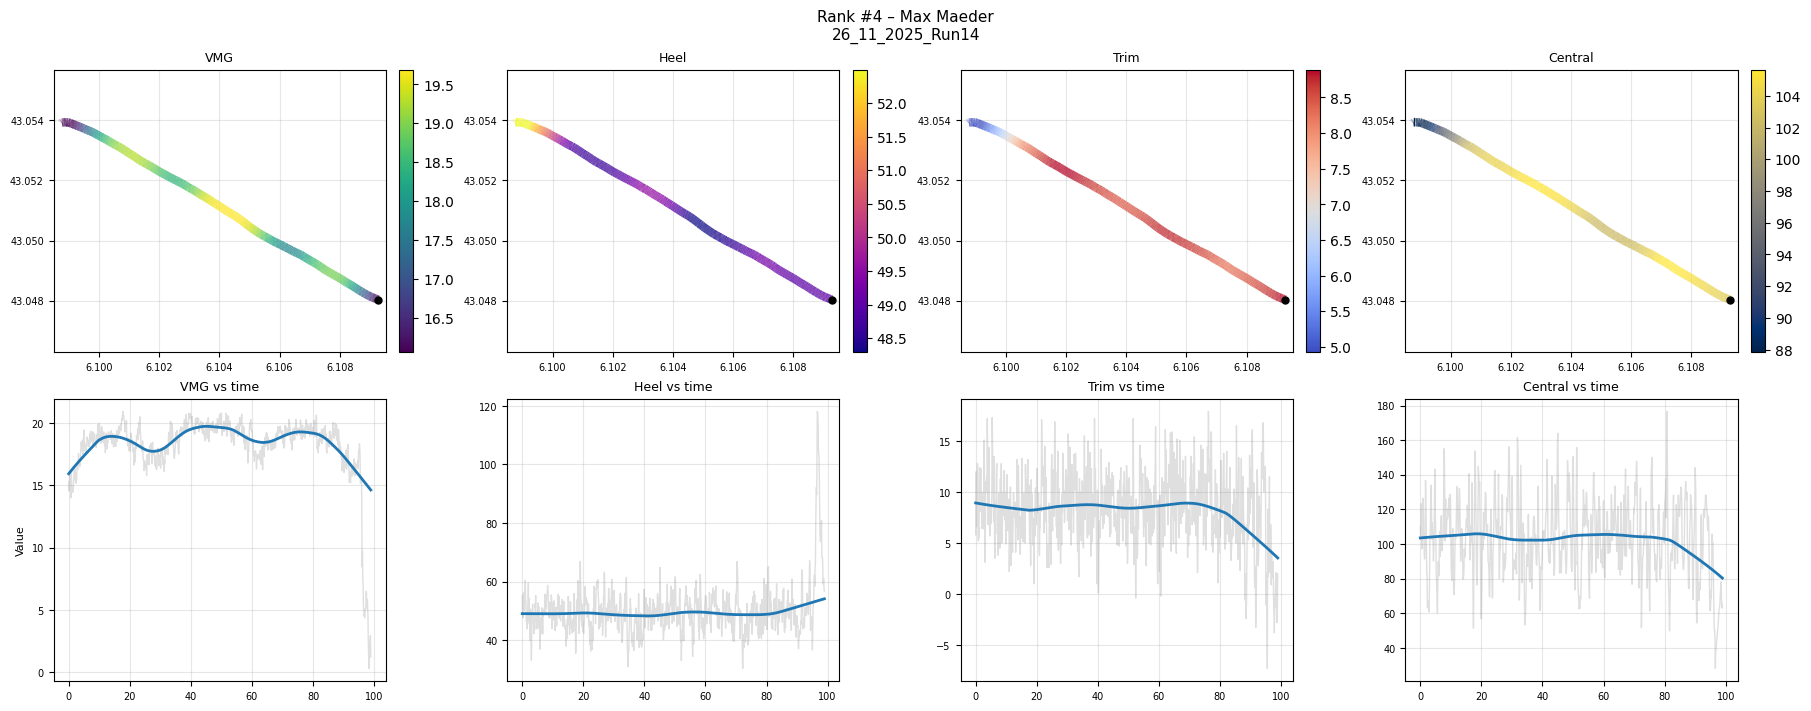

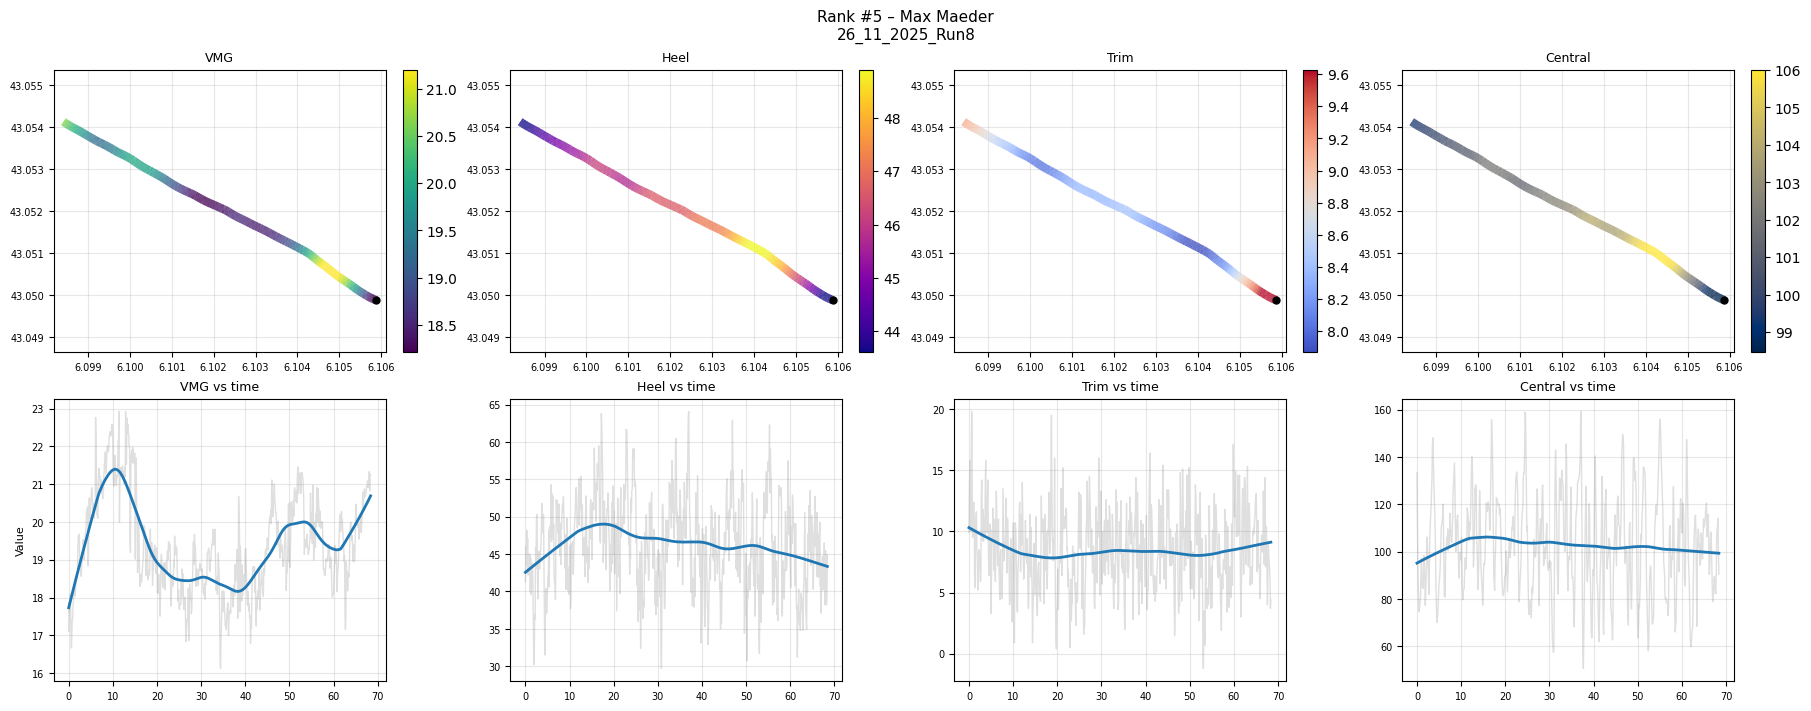

In [3]:
top_upwind_max = run_all(df_all, summary, TOP_N=10, onlyUpwind=True, rider_name="Max Maeder", smooth_frac=smooth_frac)

# Only Downwind:

## Only Gian downwind

,rank,Run,rider_name,role,pol_ratio,TWS,avg_vmg,avg_sog,avg_cog,cog_std,avg_rot,heel,trim,central,lateral,foil_brand,gain_per_min_vmg,gain_per_min_forward,gain_per_min_lateral
0,1,27_11_2025_Run2 (interval 2),Gian Stragiotti,master,109.763026,11.666677,29.338048,32.660511,155.140205,4.597073,0.128563,32.481532,11.299399,69.922671,1.314811,Chub,-30.842855,14.502076,-41.218309
1,2,26_11_2025_Run3 (interval 2),Gian Stragiotti,slave,109.755110,17.596859,32.952407,33.769573,139.646957,2.431222,-0.087514,24.368053,11.392883,57.619932,1.177911,Chub,-123.980845,93.634227,-151.438462
2,3,27_11_2025_Run1 (interval 2),Gian Stragiotti,slave,109.202900,16.444247,27.756746,33.128013,150.021910,3.468556,0.028531,26.731142,11.586854,60.654405,1.060977,Chub,-14.760235,9.831562,-11.976691
3,4,26_11_2025_Run2 (interval 2),Gian Stragiotti,master,108.396064,16.687973,31.899788,33.626544,138.520035,4.271543,-0.038648,28.280314,10.589316,63.180636,1.109120,Chub,-24.948087,21.176594,-15.672302
4,5,25_11_2025_Run1 (interval 2),Gian Stragiotti,slave,107.636077,20.244787,28.201653,32.354667,82.729946,3.293801,-0.144707,14.408000,13.410667,40.001333,1.040000,Chub,38.307637,-12.377217,56.428286
5,6,26_11_2025_Run1 (interval 1),Gian Stragiotti,slave,107.233988,15.647447,31.731597,33.879832,137.393326,3.336212,-0.003529,25.640206,11.217479,60.087583,1.005798,Chub,-31.274353,12.480192,-57.193872
6,7,25_11_2025_Run2 (interval 2),Gian Stragiotti,master,106.071791,22.628309,28.855191,31.942647,85.576975,3.353907,-0.115574,11.823529,14.313235,36.936765,1.330882,Chub,47.020890,-36.813140,32.229714
7,8,26_11_2025_Run6 (interval 2),Gian Stragiotti,master,105.124844,17.420071,30.495867,32.118581,141.133514,3.756222,0.019257,22.247331,8.520101,52.418176,1.836236,Levi,-52.086958,20.532487,-106.182033
8,9,27_11_2025_Run3 (interval 2),Gian Stragiotti,slave,103.817367,13.007730,27.657677,31.982482,145.856233,4.036410,0.032542,32.707007,11.713285,70.011301,1.089068,Chub,-3.537321,9.583293,9.624372
9,10,26_11_2025_Run8 (interval 2),Gian Stragiotti,master,103.628627,15.603825,31.230494,32.787223,137.290412,3.791966,-0.052269,30.717739,12.074957,69.680468,1.352111,Chub,-7.901115,8.485881,0.656336


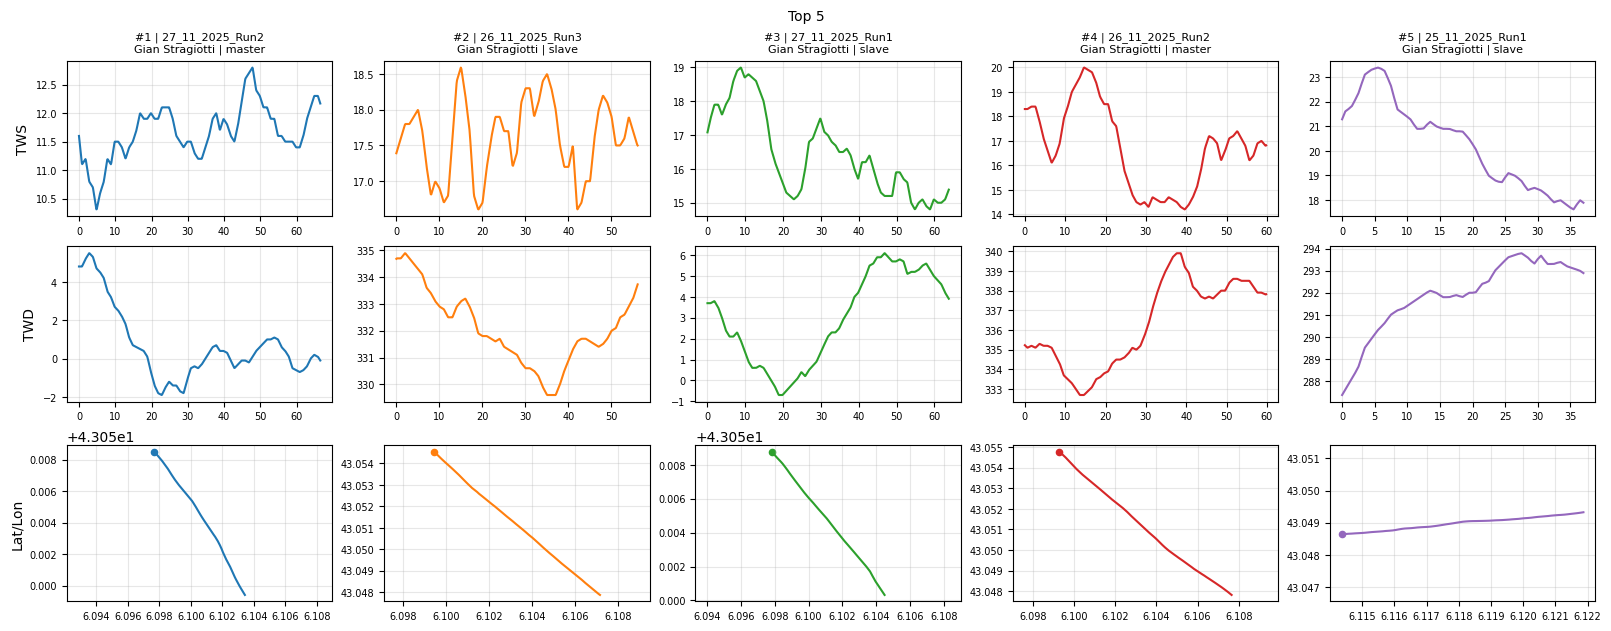

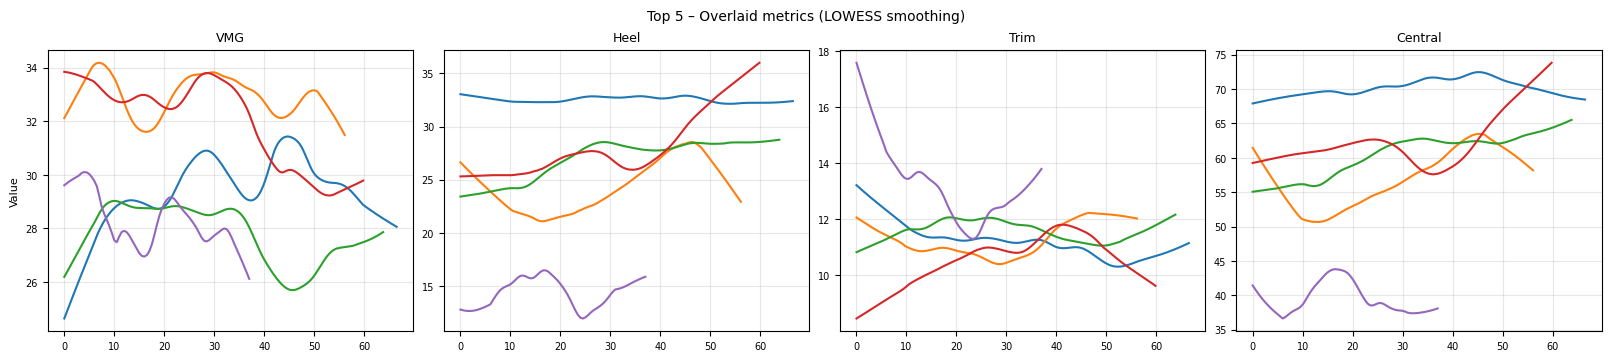

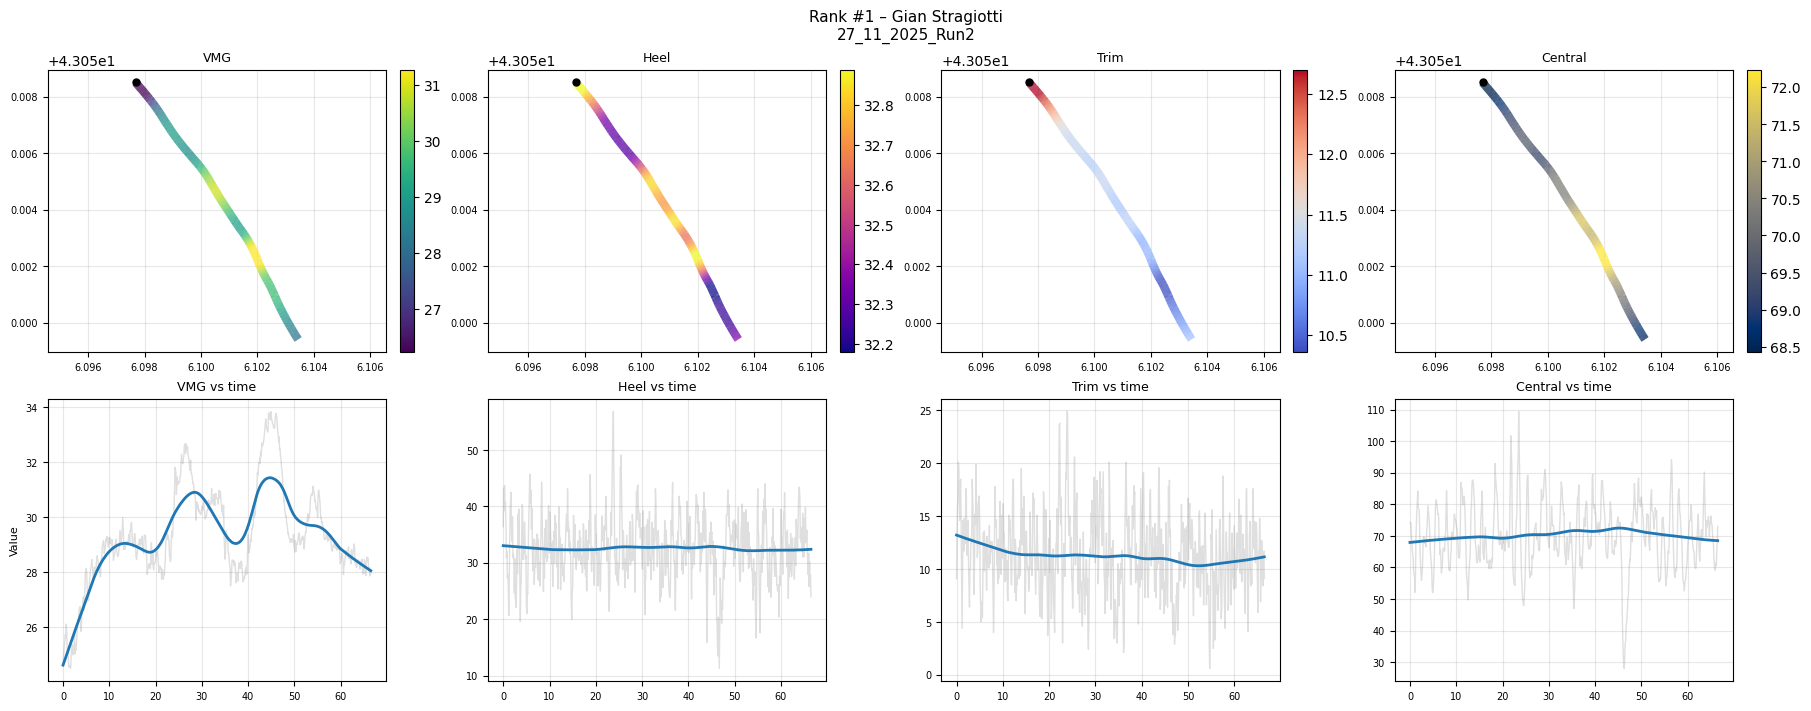

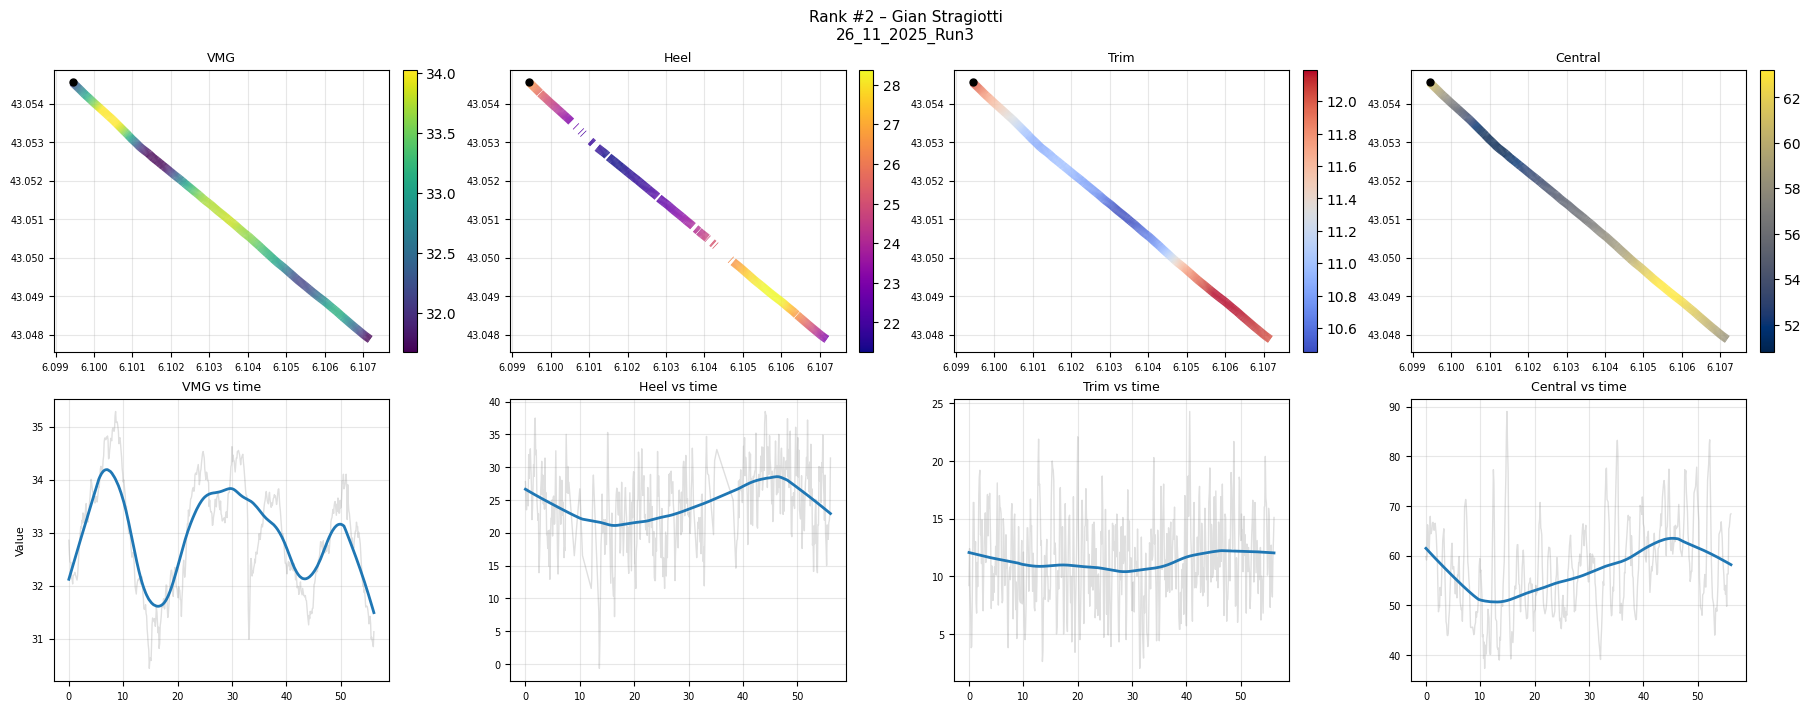

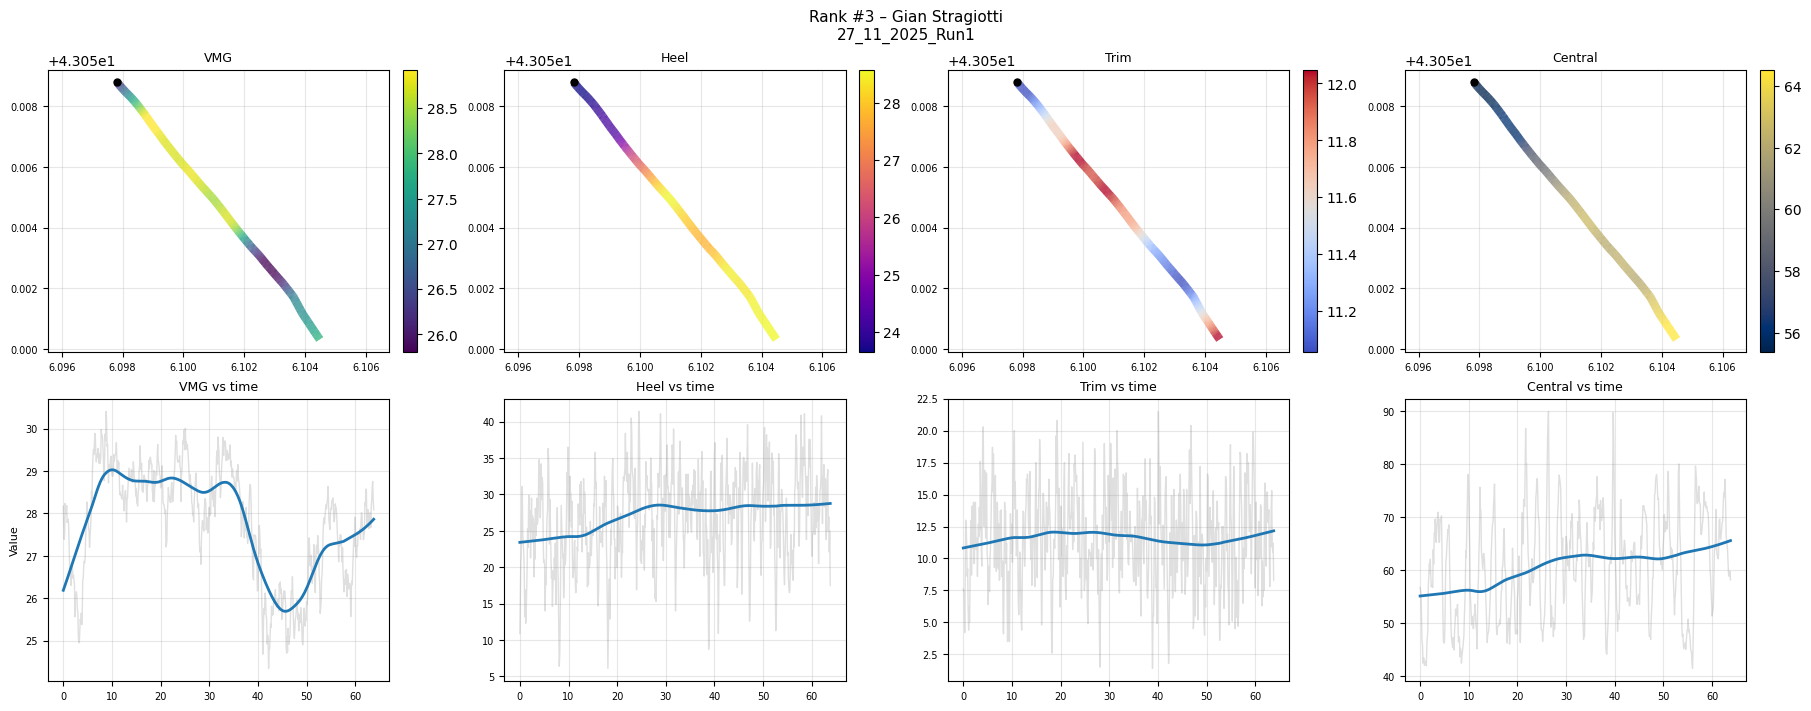

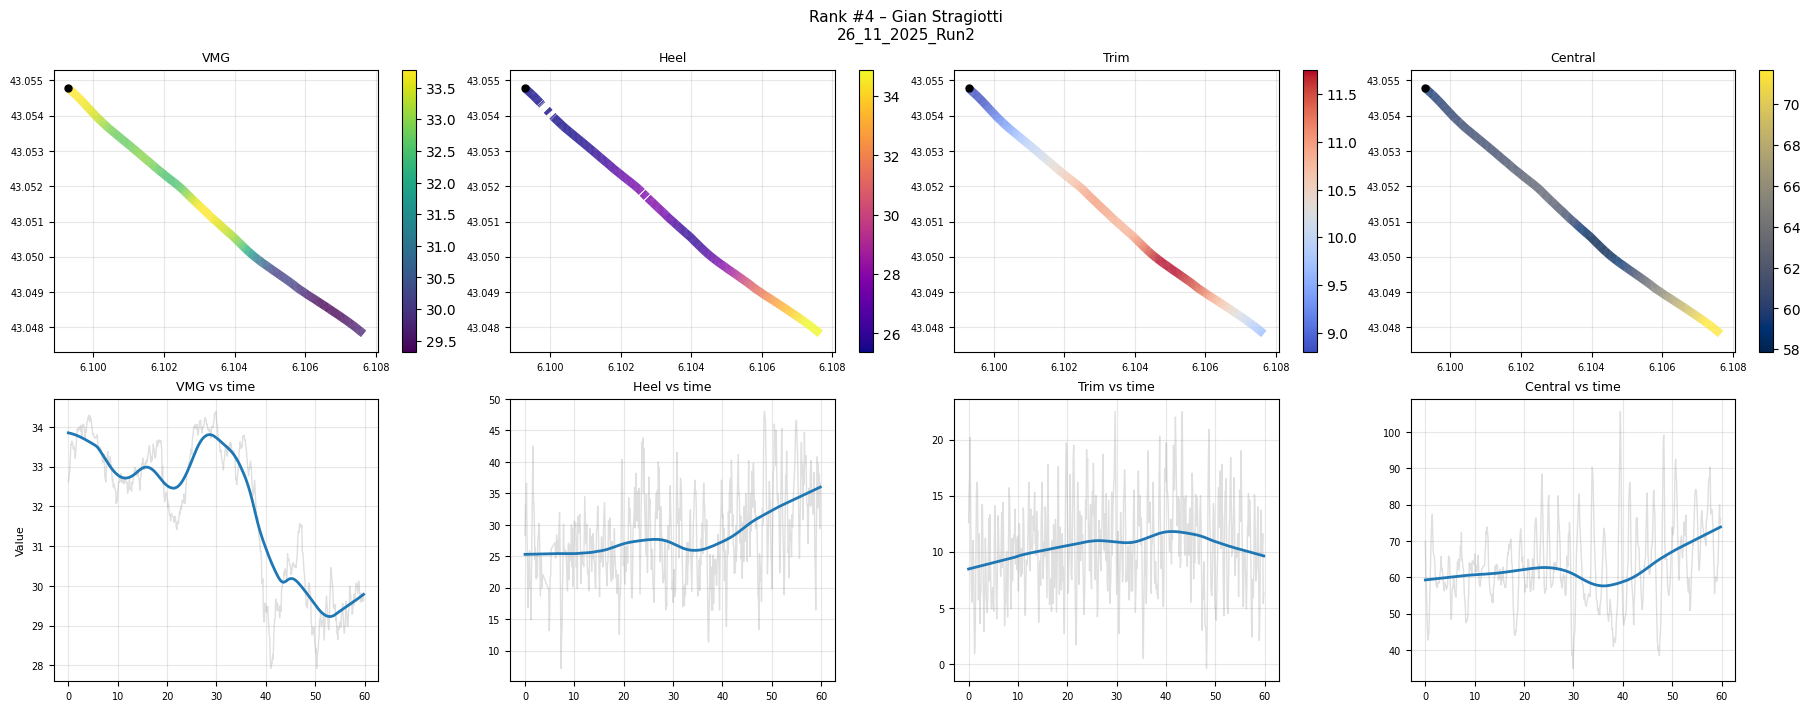

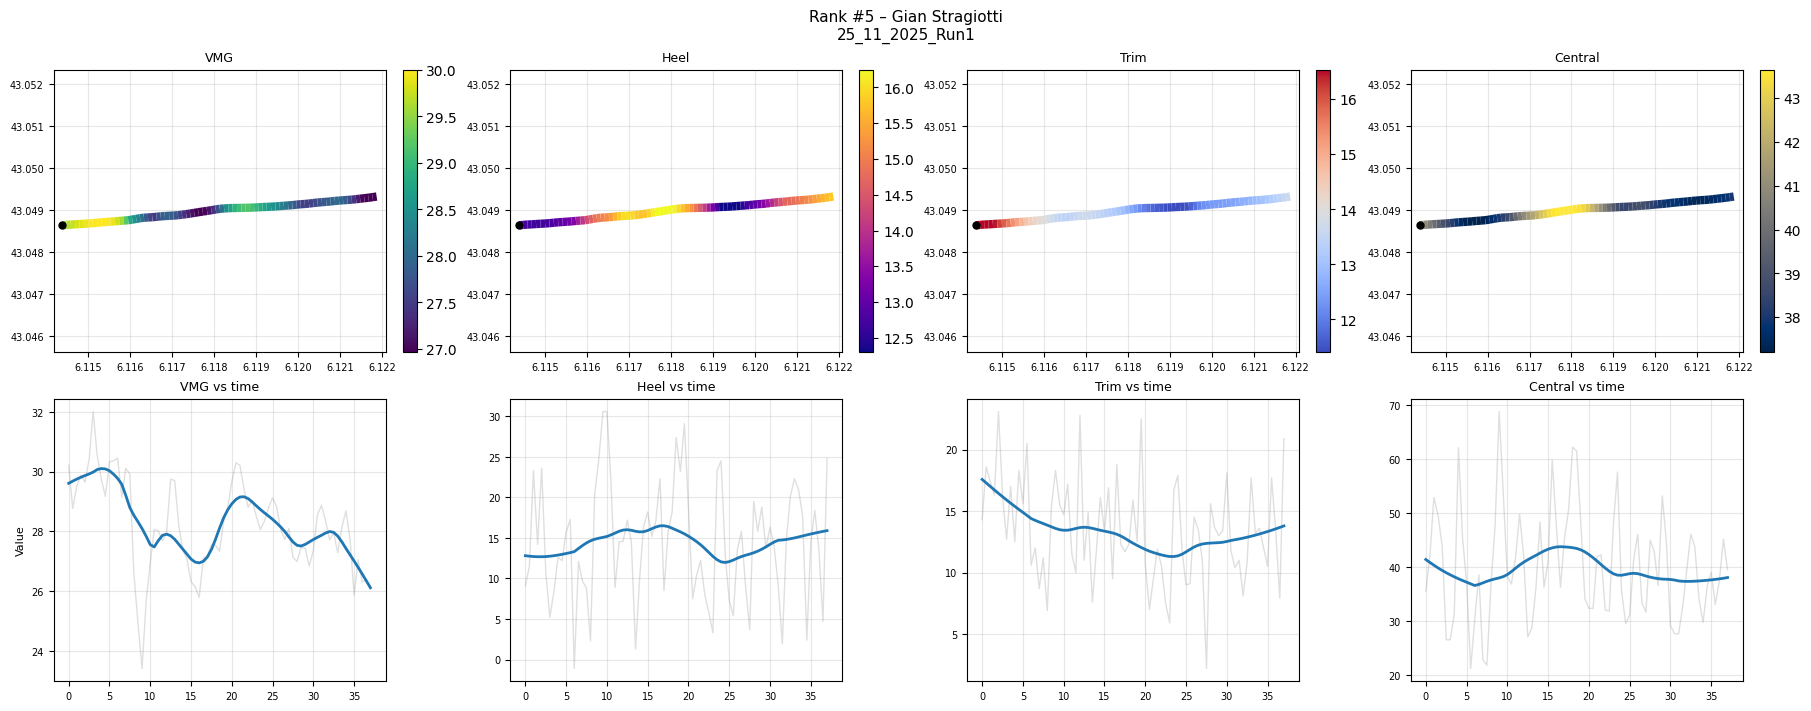

In [4]:
top_downwind_gian = run_all(df_all, summary, TOP_N=10, onlyDownwind=True, rider_name="Gian Stragiotti", smooth_frac=smooth_frac)

## Only Max downwind

,rank,Run,rider_name,role,pol_ratio,TWS,avg_vmg,avg_sog,avg_cog,cog_std,avg_rot,heel,trim,central,lateral,foil_brand,gain_per_min_vmg,gain_per_min_forward,gain_per_min_lateral
0,1,25_11_2025_Run2 (interval 2),Max Maeder,slave,110.541483,22.621696,30.548964,33.332537,87.370882,3.613027,0.086660,19.355821,10.508955,39.443493,6.735638,Levi,-47.020890,36.813140,-32.229714
1,2,26_11_2025_Run3 (interval 2),Max Maeder,master,110.368678,17.597086,28.791132,31.453119,129.696354,11.205198,0.909583,22.799460,10.538146,50.061398,3.501268,Levi,123.980845,-93.634227,151.438462
2,3,27_11_2025_Run2 (interval 2),Max Maeder,slave,109.425493,11.666693,28.419272,32.291880,152.722114,4.051181,0.116514,32.475338,7.747820,64.314418,6.086632,Levi,30.842855,-14.502076,41.218309
3,4,25_11_2025_Run1 (interval 2),Max Maeder,master,109.009056,20.252175,29.469030,32.813477,86.028383,3.462379,-0.125173,18.097035,10.480323,36.259741,5.123156,Levi,-38.307637,12.377217,-56.428286
4,5,27_11_2025_Run1 (interval 2),Max Maeder,master,108.412822,16.445755,27.224550,32.796708,149.196094,3.940044,0.464904,28.602665,8.671944,54.607588,5.727323,Levi,14.760235,-9.831562,11.976691
5,6,26_11_2025_Run2 (interval 2),Max Maeder,slave,108.260678,16.687612,31.177328,33.059197,137.611215,6.036228,0.264654,29.807024,8.244147,56.616512,3.971376,Levi,24.948087,-21.176594,15.672302
6,7,26_11_2025_Run4 (interval 2),Max Maeder,slave,107.201132,18.061090,30.772168,32.752083,136.662176,9.288609,0.777005,25.246057,7.551282,53.880878,3.841110,Chub,-15.170375,32.097897,64.564129
7,8,27_11_2025_Run3 (interval 2),Max Maeder,master,107.124666,13.006736,27.594022,31.733382,146.387992,4.138659,0.196565,34.046999,7.760176,65.160676,6.055517,Levi,3.537321,-9.583293,-9.624372
8,9,26_11_2025_Run6 (interval 2),Max Maeder,slave,107.062980,17.418168,28.873795,31.827458,134.726529,6.247637,0.451286,24.620204,9.346949,51.548266,3.441429,Chub,52.086958,-20.532487,106.182033
9,10,25_11_2025_Run6 (interval 2),Max Maeder,slave,106.219993,25.135871,30.202436,32.133071,84.599313,5.014303,-0.024260,12.664286,12.566667,NaN,NaN,Chub,-33.012657,41.647096,20.883465


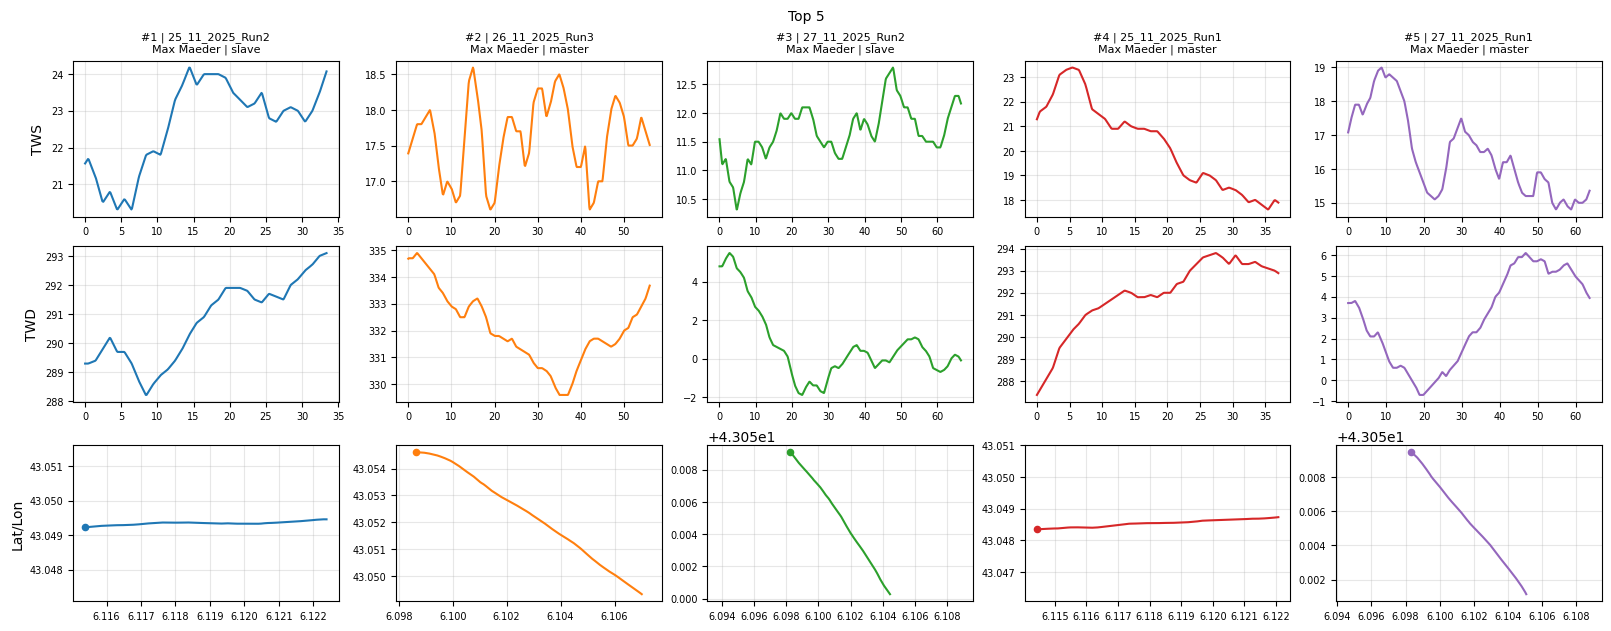

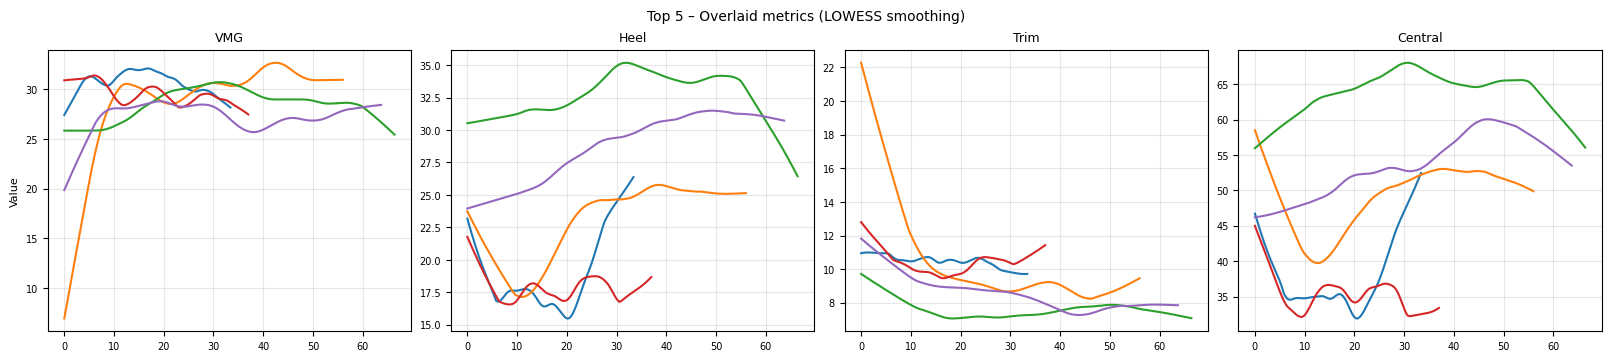

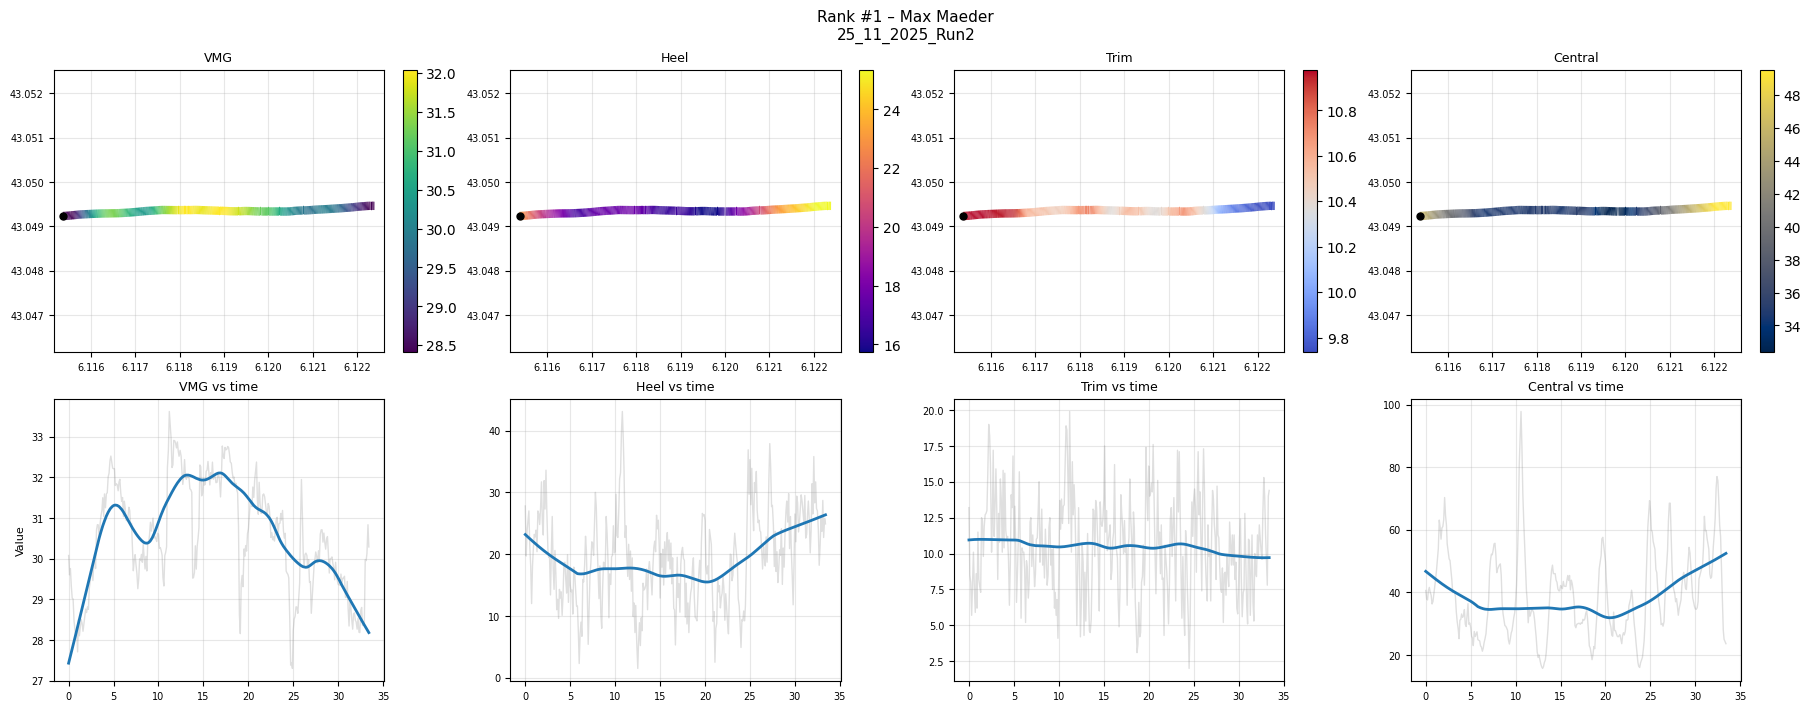

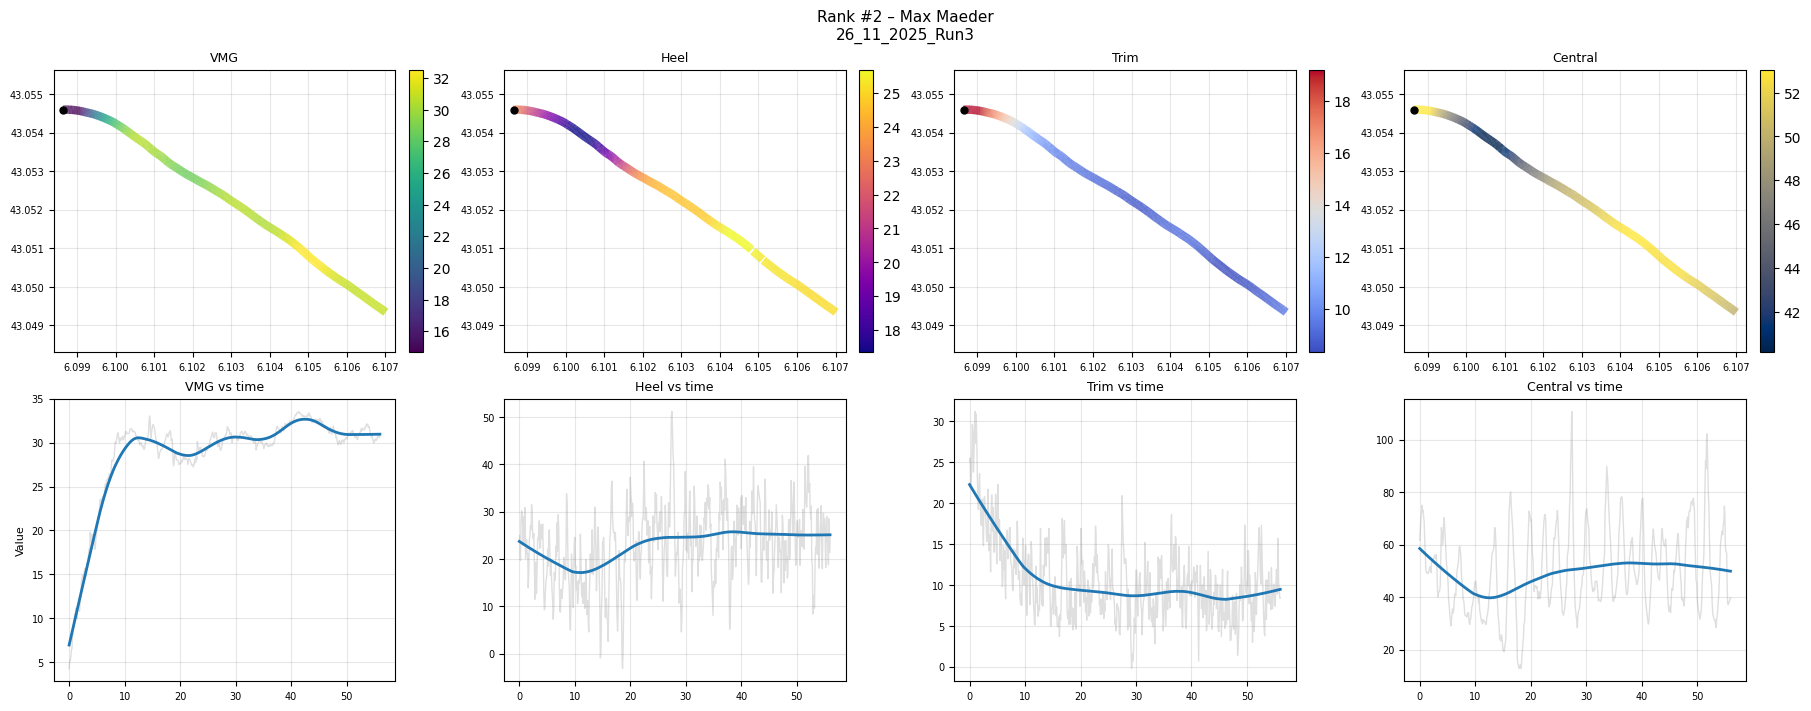

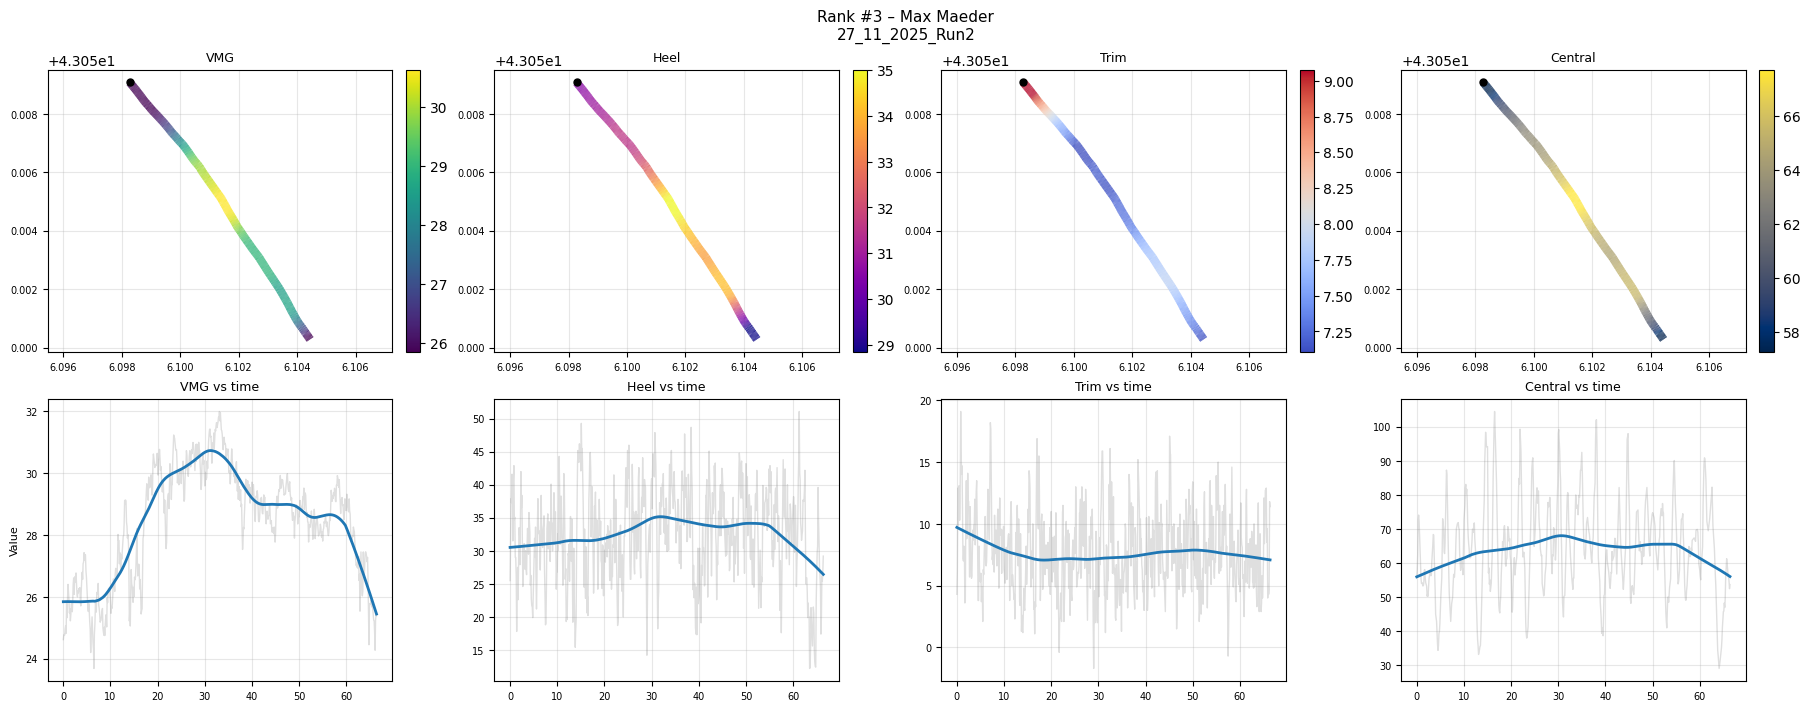

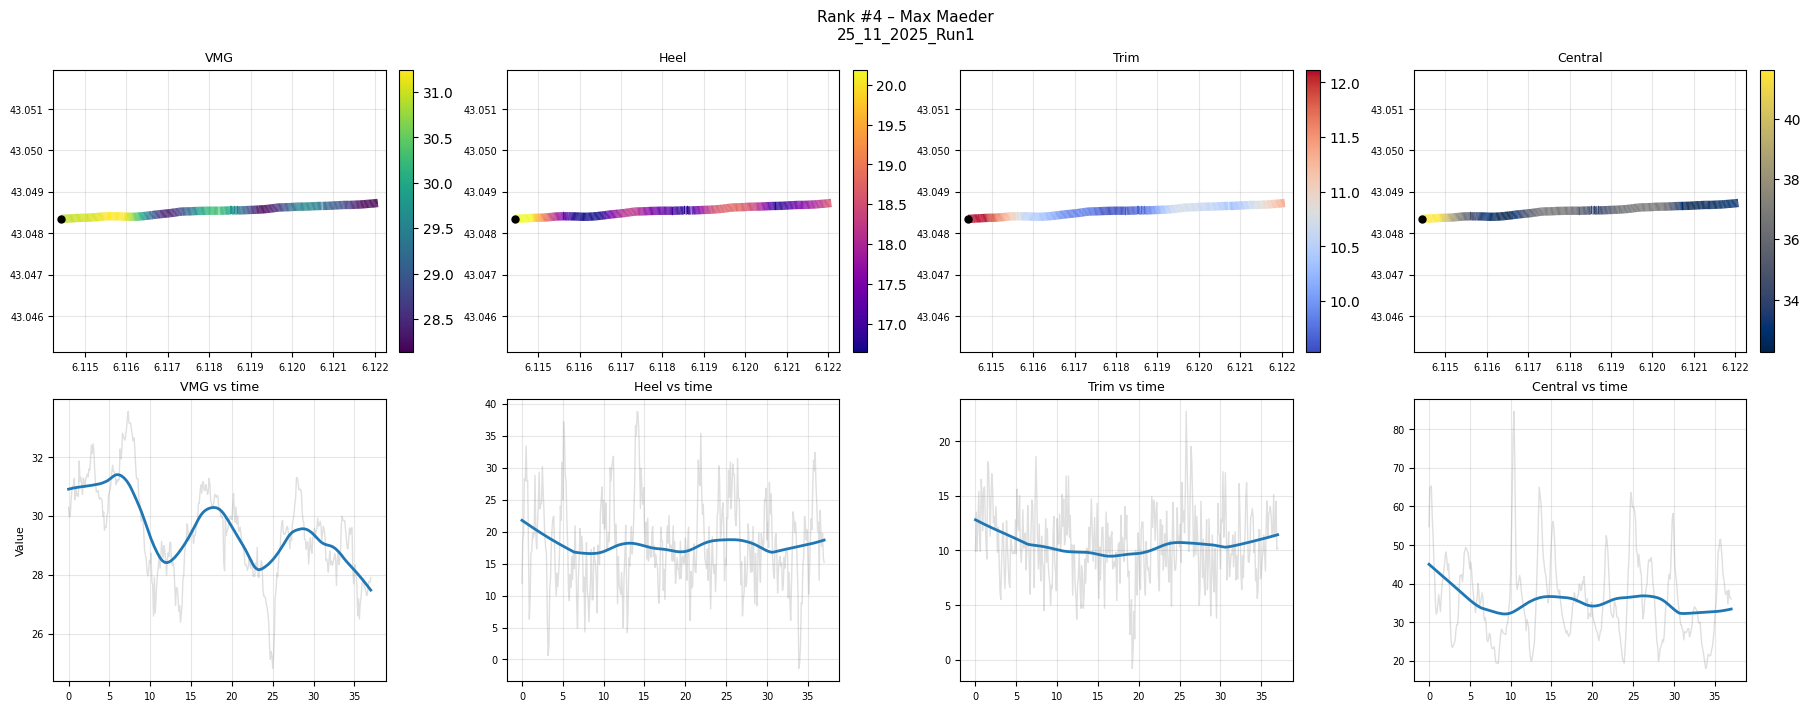

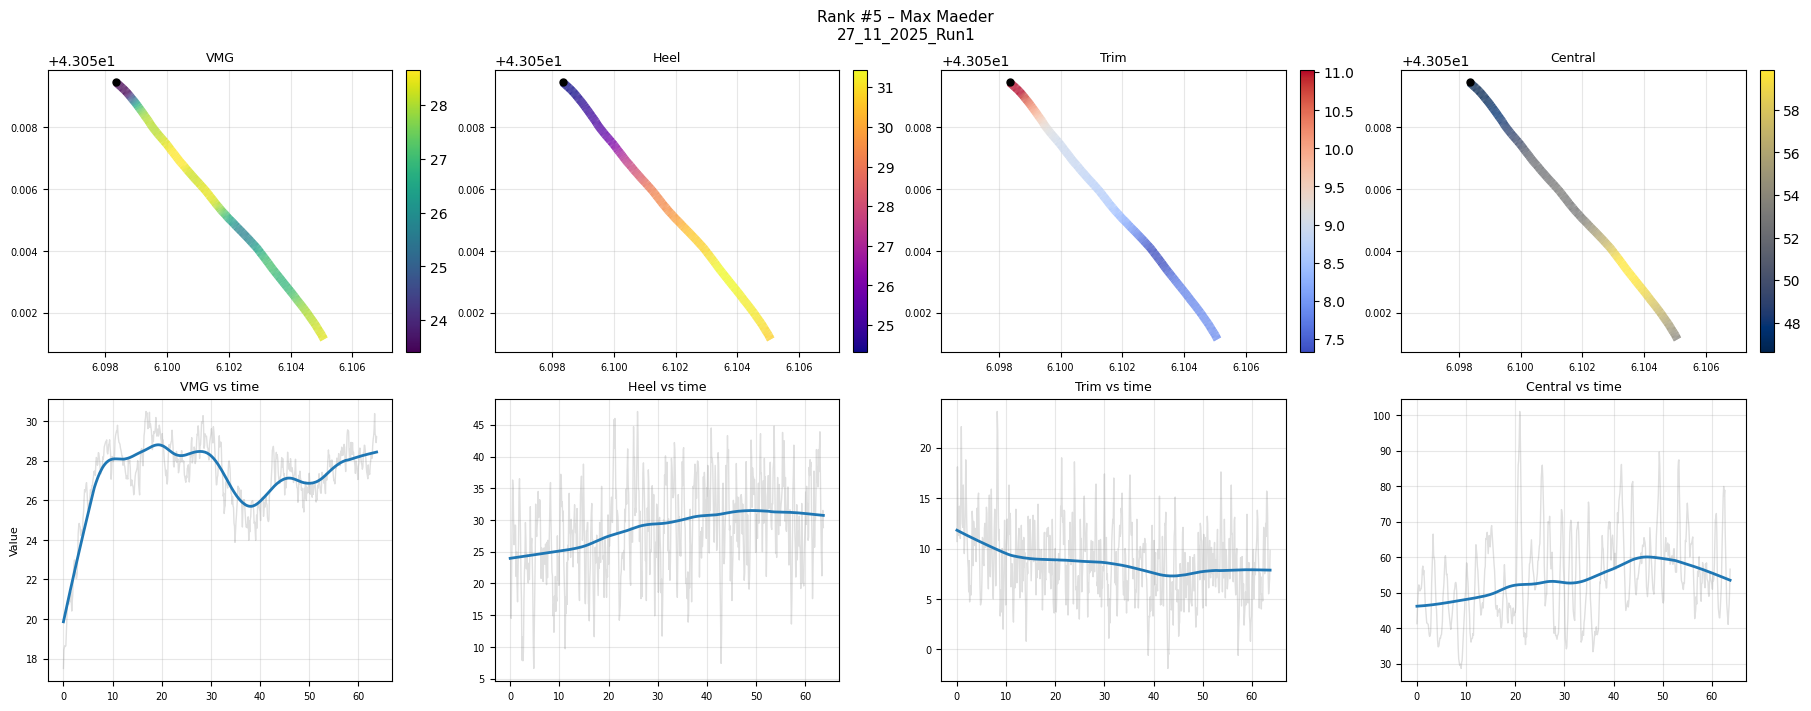

In [5]:
top_downwind_max = run_all(df_all, summary, TOP_N=10    , onlyDownwind=True, rider_name="Max Maeder", smooth_frac=smooth_frac)